# 13 — Alberta figures: every map, star grid, table and the draft deck — the complete record (mirror of the Y2Y-wide `20_figures`)

Consumes **12**'s products only. Same cartography and figure set as the Y2Y-wide record (1 km ramp with the core in yellow,
never = light grey, PA layer, clusters outlined with the deck picks numbered north → south, admin lines, 53°N), with the Alberta
rulings: **1 km is the display unit**, and **the Upper Smoky Nature-First zone and SRP planning area are drawn on every (a)
panel** in the role the declared IPCA proposals play in the Y2Y-wide package — alignment, not assignment.

**Acts follow the analysis (parent M4.33 addendum):** Act 0 where the values are (the prologue) → Act 1 the core → Act 2 the
value-specific tiers (value | tier pairing per theme) → hinge cross-tab → Act 3 the opportunity landscape as the measured gap.
**Team-output rules mirrored (M4.33):** clusters are "Cluster N" (regional, north → south); "naturalness" for 1 − gHM; T-D7
consequences tables at the end of Acts 1 and 2 (the cluster's mean value ÷ the allocatable-land mean, "2.3×", reference
columns = existing protected areas and the Upper Smoky areas' unprotected parts) and the objectives table, all rendered to
the Y2Y table spec (`director_plot.spec_table_png`); every figure takes the spec's type (`director_plot.SPEC_RC`).
**Shared assets (AB M18.6, 2026-09-15):** the Act 1 maps (the Alberta frame + ONE inset on the key core cluster), the star grid, the
cluster locators, the objectives table and the consequences tables are ONE function each in `director_plot`, loaded here with the Alberta
grid / manifest / Upper Smoky overlay / window; `14_director_outputs` calls the same functions for the presentation set.


In [1]:
import importlib, json, pathlib, sys, textwrap
import numpy as np
import pandas as pd
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Patch
from matplotlib.collections import PolyCollection
from matplotlib.colors import ListedColormap, BoundaryNorm, Normalize
from matplotlib.cm import ScalarMappable
from types import SimpleNamespace
from pyproj import Transformer

_cands = [p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.py").exists()]
assert _cands, "config.py not found above the notebook"
ROOT = _cands[0]
sys.path.insert(0, str(ROOT))
import config, leverage_core as lc, ensemble_core as ec, director_core as dc, director_plot as dp
for _m in (config, lc, ec, dc, dp):
    importlib.reload(_m)

HERE = ROOT / "analyses" / "alberta_prioritization"
PKG = HERE / "director_package"; GEO, TAB, FIGD = PKG / "geotiffs", PKG / "tables", PKG / "figures"
assert (PKG / "summary.json").exists(), "run 12_tiers_and_clusters first"
S = json.loads((PKG / "summary.json").read_text())
assert S.get("version", "v1") == config.Y2Y_VERSION, f"the package on disk is {S.get('version', 'v1')}, config is {config.Y2Y_VERSION} -- run 12 first"
BANDPCT = int(S["band"][1:])                                  # the applied band (D-AB13), e.g. "g05" -> 5
AB = config.AB_HANDOFF_DIR
with rasterio.open(AB / "cost_uniform.tif") as src:
    tr, shp, prof = src.transform, src.shape, src.profile
pu = lc.pu_mask(AB)
with rasterio.open(AB / "mask_protected_areas.tif") as src:
    locked2d = (src.read(1) == 1) & pu
G = SimpleNamespace(pu=pu, locked2d=locked2d, locked=locked2d[pu], disc=~locked2d[pu], n_pu=int(pu.sum()), n_disc=int((~locked2d[pu]).sum()),
                    shape=shp, transform=tr, crs=config.TARGET_CRS, profile=prof, cell_km2=abs(tr.a * tr.e) / 1e6)
G.rows, G.cols = np.where(pu)
MAN = dc.package_manifest(pd.read_csv(config.ab_paths().manifest))
def rd(name):
    with rasterio.open(GEO / name) as src:
        return src.read(1)[G.pu]
Fg, Fp, Ug = rd("F_guarded.tif"), rd("F_unguarded.tif"), rd("union_membership_guarded.tif")
with rasterio.open(GEO / "act_tiers_guarded.tif") as src:
    TIERS = src.read(1)
LAB = dict(np.load(GEO / "cluster_labels.npz"))
PICKS = pd.read_csv(TAB / "picks.csv", dtype={"number": str, "cids": str})
TD1 = pd.read_csv(TAB / "T-D1_cluster_register.csv", dtype={"number": str})
TD2a, TD2b = pd.read_csv(TAB / "T-D2_bands.csv"), pd.read_csv(TAB / "T-D2_acts.csv")
TD3 = pd.read_csv(TAB / "T-D3_scenarios.csv")
TD7 = pd.read_csv(TAB / "T-D7_consequences.csv")                       # consequences record: picks + reference rows (12)
SV, BIO = S["value"], S["biodiversity_plan_capture"]                         # v1.6 products from 12
VAL = {t: rd(f"value_top30_{t.replace(' ', '_')}.tif") > 0 for t in dc.VALUE_THEMES + ["naturalness"]}
CONV, GAP = rd("value_convergence.tif"), rd("value_gap.tif")
XT = pd.read_csv(TAB / "hinge_crosstab.csv", index_col=0); TD6 = pd.read_csv(TAB / "T-D6_value_coverage.csv")
POOL = {}
for rec in S["pooling"]:
    sid = rec["scenario"]; fids = [f for f in MAN[MAN.scenario_id == sid].formulation_id if f in S["forms"]]
    if rec["decision"].startswith("POOLED"): POOL[sid] = np.mean([rd(f"f_guarded_{f}.tif") for f in fids], axis=0)
    elif rec["decision"].startswith("SEPARATE"):
        for f in fids: POOL[f"{sid}@{'245' if 'ssp245' in f else '585'}"] = rd(f"f_guarded_{f}.tif")
    else: POOL[sid] = rd(f"f_guarded_{fids[0]}.tif")
assert set(POOL) == set(S["pool_keys"]), "pooling keys drifted from 12"
CL = {lyr: gpd.read_file(GEO / "clusters.gpkg", layer=lyr) for lyr in gpd.list_layers(GEO / "clusters.gpkg").name}
AOI = gpd.read_file(GEO / "aoi.gpkg")
HEX_KM2_AB = 25
HEX = {HEX_KM2_AB: dc.hex_grid(G, HEX_KM2_AB)}      # comparison only (D-AB7: Alberta is shown at 1 km)

# ---- cartography (pixel space: 1 px = 1 km), the parent's rules; AB window ----------------------------------------
halo = [pe.withStroke(linewidth=2.5, foreground="white")]
BAND_COLORS = ["#f2f2f2", "#1f3a63", "#5b87ad", "#ffd93b", "#e6550d"]
BAND_BOUNDS = [-0.001, 0.05, 0.30, 0.70, 0.95, 1.001]
BAND_NAMES = ["never (<5% of plans)", "rare (5-30%)", "conditional (30-70%)", "frequent (70-95%)", "always (>=95%)"]
PA_COLOR, AOI_COLOR, CL_COLOR = "#8f8f8f", "#ff6a00", "crimson"     # AOI orange = the parent's IPCA colour
FCMAP = ListedColormap(plt.get_cmap("viridis")(np.linspace(0, 0.70, 256))); FCMAP.set_over("#ffd93b")
NEVER_COLOR = "#e6e6e6"; FCMAP.set_under(NEVER_COLOR)
FNORM = Normalize(1e-9, dc.FREQ_THR)
N_NOTE = (f"n = {S['n_formulations']} value positions x 51 near-optimal plans - {BANDPCT}% band - "
          f"no value theme left more than {100 * S['floor_g']:.0f}% behind - additions {S['additions_km2']:,} km2 (level A)")
PAg = np.full(G.shape, np.nan, np.float32); PAg[G.locked2d] = 1.0
rows_, cols_ = np.where(G.pu.any(axis=1))[0], np.where(G.pu.any(axis=0))[0]
R0, R1, C0, C1 = max(rows_.min() - 10, 0), min(rows_.max() + 11, G.shape[0]), max(cols_.min() - 10, 0), min(cols_.max() + 11, G.shape[1])
T_LL = Transformer.from_crs("EPSG:4326", G.crs, always_xy=True)

def rings_px(geom):
    polys = geom.geoms if geom.geom_type == "MultiPolygon" else [geom]
    out = []
    for p in polys:
        x, y = np.asarray(p.exterior.coords)[:, :2].T; px, py = dc.xy_to_px(G, x, y); out.append(np.c_[px, py])
    return out
def draw_pa(ax): ax.imshow(PAg, cmap=ListedColormap([PA_COLOR]), interpolation="nearest", zorder=1)
def draw_surface(ax, v1d, cmap=FCMAP, norm=FNORM):
    g2 = dc.to_grid(G, np.where(G.disc, v1d, np.nan).astype(np.float32))
    ax.imshow(g2, cmap=cmap, norm=norm, interpolation="nearest", zorder=0.5)
def draw_hex(ax, hm, cmap, norm):
    ok = hm[np.isfinite(hm.value)]
    ax.add_collection(PolyCollection([rings_px(g)[0] for g in ok.geometry], facecolors=cmap(norm(ok.value.values)), edgecolors="none", zorder=0.5))
    ax.set_aspect("equal")
def draw_clusters(ax, layer, numbers, color=CL_COLOR, lw=0.9, fs=10):
    g = CL.get(layer)
    if g is None: return
    for _, r in g.iterrows():
        for ring in rings_px(r.geometry): ax.plot(ring[:, 0], ring[:, 1], color=color, lw=lw, zorder=4)
        if int(r.cid) in numbers and numbers[int(r.cid)][1]:
            c = r.geometry.centroid; cx, cy = dc.xy_to_px(G, c.x, c.y)
            ax.annotate(numbers[int(r.cid)][0], xy=(cx, cy), xytext=(cx + 18, cy - 18), fontsize=fs, fontweight="bold", color=color,
                        path_effects=halo, zorder=6, arrowprops=dict(arrowstyle="-", color=color, lw=0.6))
def draw_aoi(ax, lw=1.3):
    for _, r in AOI.iterrows():
        ls = "-" if "Nature-First" in r["name"] else (0, (4, 2))
        for ring in rings_px(r.geometry): ax.plot(ring[:, 0], ring[:, 1], color=AOI_COLOR, lw=lw, ls=ls, zorder=3.5)
AOI_HANDLES = [Patch(facecolor="none", edgecolor=AOI_COLOR, label="Upper Smoky Nature-First zone (not locked in)"),
               Patch(facecolor="none", edgecolor=AOI_COLOR, linestyle="--", label="Upper Smoky SRP planning area (not locked in)")]
from affine import Affine
GWIN = SimpleNamespace(transform=Affine(G.transform.a, 0, G.transform.c + C0 * G.transform.a, 0, G.transform.e, G.transform.f + R0 * G.transform.e),
                       shape=(R1 - R0, C1 - C0), crs=G.crs)
ADMIN = dc.admin_layer(GWIN, pad_m=60e3)         # basemap clipped to the Alberta window; drawn in full-grid pixel space
def scalebar(ax, km=100):
    x0 = C0 + 0.62 * (C1 - C0); y0 = R0 + 0.06 * (R1 - R0)
    ax.plot([x0, x0 + km], [y0, y0], color="black", lw=2.5, solid_capstyle="butt", zorder=5)
    ax.text(x0 + km / 2, y0 - 6, f"{km} km", ha="center", fontsize=8, zorder=5)
def finish(ax, title, handles, note=N_NOTE, legend_side="right", scale=True):
    dc.draw_admin(ax, G, ADMIN)
    dc.graticule(ax, G, lats=(53,), lons=(), emph_lat=53)
    ax.set_xlim(C0, C1); ax.set_ylim(R1, R0)
    for t in ax.texts:                                   # drop labels that fall outside the window (they would inflate the tight bbox)
        x_, y_ = t.get_position()                        # ...and the US state labels, which crowd the southern tip
        if not (C0 <= x_ <= C1 and R0 <= y_ <= R1) or t.get_text() in ("WA", "ID", "MT", "OR", "NV", "UT", "WY", "CA"): t.set_visible(False)
    x53, y53 = dc.xy_to_px(G, *T_LL.transform(-119.6, 53.0))    # re-label the 53 N line inside the window (the module's label lands off-window)
    ax.text(x53 + 4, y53 - 4, "53\u00b0N", fontsize=8, color="#b00020", fontweight="bold", zorder=4)
    if scale: scalebar(ax)
    dc.corner_note(ax, note)
    ax.set_title(title, fontsize=10.5); ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)
    if handles:                                           # outside the panel: the strip fills the narrow axes
        if legend_side == "left": ax.legend(handles=handles, loc="upper right", bbox_to_anchor=(-0.02, 0.98), fontsize=8, frameon=True)
        else: ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 0.98), fontsize=8, frameon=True)
def picks_for(act, key=None):
    p = PICKS[PICKS.act == act]
    if key is not None: p = p[p.key == key]
    out = {}
    for _, r in p.iterrows():
        for c in str(r.cids).split(";"): out[int(c)] = (str(r.number), int(c) == int(r.cid))
    return out
BASE_HANDLES = [Patch(facecolor=PA_COLOR, label="Existing protected areas (locked in; never a recommendation)"),
                Patch(facecolor=NEVER_COLOR, edgecolor="#bbbbbb", label="never selected (F = 0)"),
                Patch(facecolor="none", edgecolor=CL_COLOR, label="numbered = deck picks")]
def table_png(df, path, title, fs=7.5, scale=1.45):
    fig, ax = plt.subplots(figsize=(min(1.6 * len(df.columns) + 2, 22), 0.42 * len(df) + 1.6)); ax.axis("off")
    t = ax.table(cellText=df.values, colLabels=df.columns, cellLoc="center", loc="center")
    t.auto_set_font_size(False); t.set_fontsize(fs); t.scale(1, scale)
    for j in range(len(df.columns)): t[0, j].set_facecolor("#2b4f7d"); t[0, j].set_text_props(color="white", fontweight="bold")
    ax.set_title(title, fontsize=11, pad=12); fig.savefig(path, dpi=200, bbox_inches="tight"); plt.show()
def colorbar(fig, label="F = frequency in near-optimal plans; light grey = never (F = 0), yellow = core (F >= 0.70)"):
    cax = fig.add_axes([0.30, 0.055, 0.40, 0.014])
    fig.colorbar(ScalarMappable(norm=FNORM, cmap=FCMAP), cax=cax, orientation="horizontal", extend="both", label=label)
print(f"loaded package: {len(S['forms'])} positions | pool keys {list(POOL)} | cluster layers {list(CL)} | window {R1-R0}x{C1-C0} km")
plt.rcParams.update(dp.SPEC_RC)          # every figure takes the table spec's type (Cronos Pro, ink/cap/mut), as the parent's 20 does

# ---- the SHARED assets (director_plot; 14_director_outputs calls the same functions) -- the package loaded through dp.load with
# the Alberta grid, manifest, the Upper Smoky overlay in the IPCA role and the Alberta window (AB M18.6); STYLE knobs BEFORE load
AB_TOWNS = tuple(t for t in ("Jasper", "Edmonton", "Calgary", "Banff") if t in dc.Y2Y_TOWNS)
dp.STYLE.update(pa_layer_min_km2=50, window_scale_km=100, inset_min_km=160, inset_pad_km=25, towns=AB_TOWNS,
                wide_main_towns=AB_TOWNS, wide_main_names="abbrev", lat53=False)
OVERLAY = SimpleNamespace(gdf=AOI.assign(ls=["-" if "Nature-First" in n else (0, (4, 2)) for n in AOI.name]),
                          mask2d=None,
                          label="Upper Smoky areas of interest (not locked in)")
WIN = (float(C0), float(C1), float(R0), float(R1))                       # the Alberta strip (pixel window: x0, x1, y_top, y_bottom)
C = dp.load(pkg=PKG, grid=G, manifest=config.ab_paths().manifest, overlay=OVERLAY, window=WIN, hex_grid=False)
KEY = int(PICKS[PICKS.act == "Act 1"].sort_values("km2", ascending=False).iloc[0].number) if len(PICKS[PICKS.act == "Act 1"]) else None
dp.STYLE["inset_clusters"] = (KEY,) if KEY is not None else ()              # ONE inset on the key core cluster (the largest; override here)
print(f"director_plot package loaded for Alberta: window {WIN}, key cluster {KEY}, overlay = {list(OVERLAY.gdf.name)}")


loaded package: 12 positions | pool keys ['s0', 's1', 's2', 's3', 's4', 's5'] | cluster layers ['act1', 'act2_s1', 'act2_s2', 'act1_585', 'act1_245'] | window 870x336 km


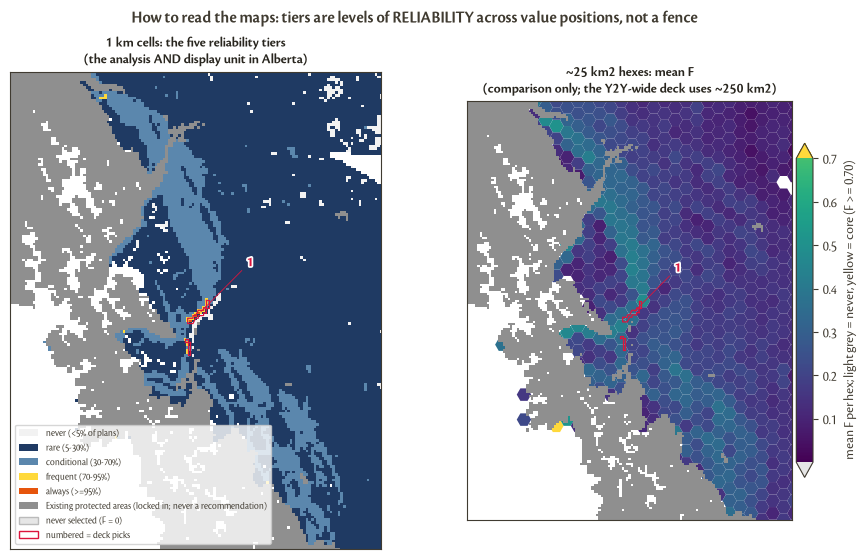

In [2]:
# ---- slide 2: how to read the map (1 km tiers vs ~25 km2 hex, zoom on pick 1) ------------------------------------------
lab1 = LAB["act1"]
if len(PICKS[PICKS.act == "Act 1"]):
    p1 = PICKS[PICKS.act == "Act 1"].iloc[0]; rr_, cc_ = np.where(lab1 == int(p1.cid))
else:                                                    # no core pick: zoom on the densest 2%-band land instead
    rr_, cc_ = np.where(dc.to_grid(G, np.where(G.disc, Fg, 0), fill=0) >= np.quantile(Fg[G.disc], 0.99))
r0, r1 = max(int(rr_.mean()) - 90, 0), min(int(rr_.mean()) + 90, G.shape[0]); c0, c1 = max(int(cc_.mean()) - 70, 0), min(int(cc_.mean()) + 70, G.shape[1])
fig, axes = plt.subplots(1, 2, figsize=(11, 6.2))
Fg2 = dc.to_grid(G, np.where(G.disc, Fg, np.nan))
axes[0].imshow(Fg2, cmap=ListedColormap(BAND_COLORS), norm=BoundaryNorm(BAND_BOUNDS, 5), interpolation="nearest")
axes[0].set_title("1 km cells: the five reliability tiers\n(the analysis AND display unit in Alberta)", fontsize=10)
gdf, hl = HEX[HEX_KM2_AB]; draw_hex(axes[1], dc.hex_means(G, gdf, hl, Fg), FCMAP, FNORM)
axes[1].set_title(f"~{HEX_KM2_AB} km2 hexes: mean F\n(comparison only; the Y2Y-wide deck uses ~250 km2)", fontsize=10)
for ax in axes:
    draw_pa(ax); draw_clusters(ax, "act1", picks_for("Act 1")); ax.set_xlim(c0, c1); ax.set_ylim(r1, r0); ax.set_xticks([]); ax.set_yticks([])
axes[0].legend(handles=[Patch(facecolor=c, label=n) for c, n in zip(BAND_COLORS, BAND_NAMES)] + BASE_HANDLES, loc="lower left", fontsize=7, frameon=True)
fig.colorbar(ScalarMappable(norm=FNORM, cmap=FCMAP), ax=axes[1:], shrink=0.7, extend="both", pad=0.01, label="mean F per hex; light grey = never, yellow = core (F >= 0.70)")
fig.suptitle("How to read the maps: tiers are levels of RELIABILITY across value positions, not a fence", fontsize=12)
fig.savefig(FIGD / "slide2_how_to_read.png", dpi=170, bbox_inches="tight"); plt.show()

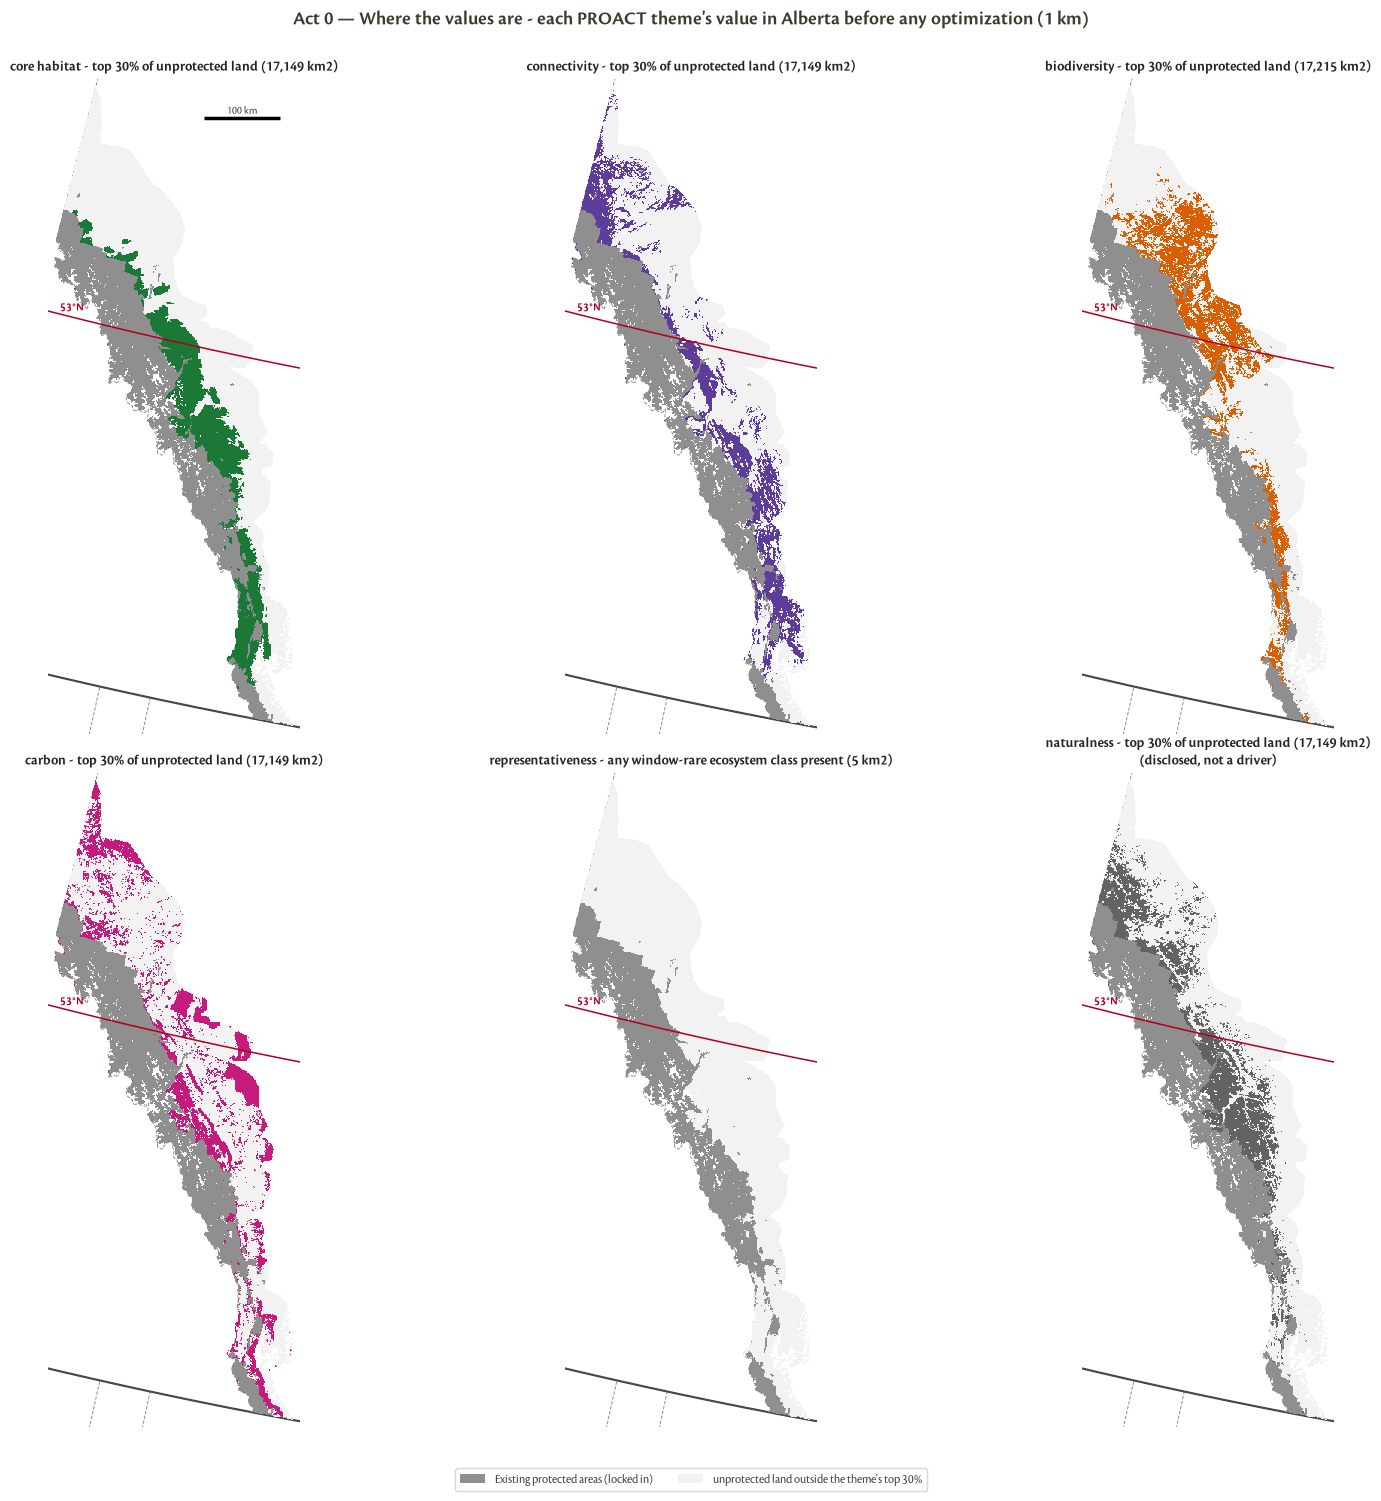

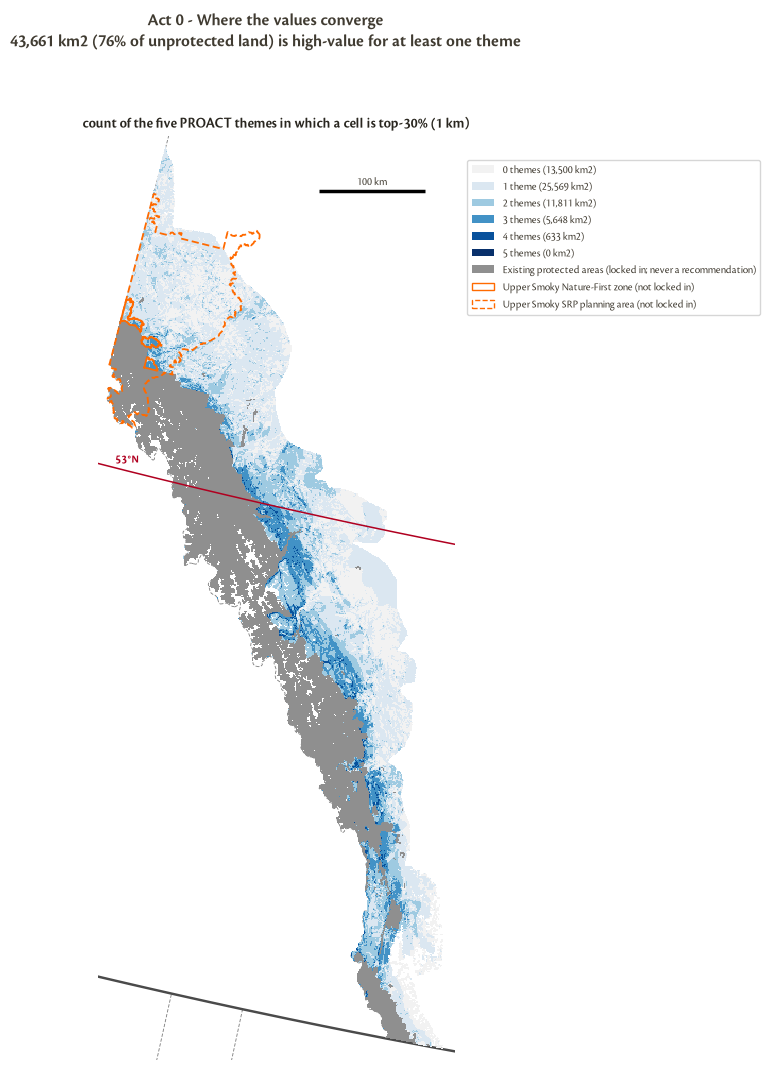

In [3]:
# ---- Act 0: where the values are (top-30% of unprotected land per theme, at 1 km) + value convergence -------------------------
themes = dc.VALUE_THEMES + ["naturalness"]
TCOL = {"core habitat": "#1b7837", "connectivity": "#5e3c99", "biodiversity": "#d95f02", "carbon": "#c51b7d", "representativeness": "#0570b0", "naturalness": "#636363"}
fig, axes = plt.subplots(2, 3, figsize=(16, 15.5)); fig.subplots_adjust(left=0.02, right=0.98, top=0.92, bottom=0.05, wspace=0.03, hspace=0.06)
for ax, t in zip(axes.ravel(), themes):
    g2 = dc.to_grid(G, np.where(G.disc, VAL[t].astype(np.float32), np.nan))
    ax.imshow(np.where(g2 > 0, 1.0, np.nan), cmap=ListedColormap([TCOL[t]]), interpolation="nearest", zorder=0.5)
    ax.imshow(np.where(g2 == 0, 1.0, np.nan), cmap=ListedColormap(["#f2f2f2"]), interpolation="nearest", zorder=0.4)
    draw_pa(ax)
    km2 = SV["footprint_km2"][t]
    ttl = (f"{t} - any window-rare ecosystem class present ({km2:,} km2)" if t == "representativeness" else f"{t} - top 30% of unprotected land ({km2:,} km2)")
    if t == "naturalness": ttl += "\n(disclosed, not a driver)"
    finish(ax, ttl, None, note="", scale=(t == themes[0]))
fig.legend(handles=[Patch(facecolor=PA_COLOR, label="Existing protected areas (locked in)"), Patch(facecolor="#f2f2f2", label="unprotected land outside the theme's top 30%")],
           loc="lower center", ncol=2, fontsize=9, frameon=True, bbox_to_anchor=(0.5, 0.005))
fig.suptitle(dc.ACT_TITLE["act0"] + " - each PROACT theme's value in Alberta before any optimization (1 km)", fontsize=14, y=0.965)
fig.savefig(FIGD / "act0_values_1km.png", dpi=170, bbox_inches="tight"); plt.show()
# value convergence: number of the five PROACT themes (0-5) rating a cell top-30%
CCMAP = ListedColormap(["#f2f2f2", "#dbe7f1", "#9ecae1", "#4292c6", "#08519c", "#08306b"])
fig, ax = plt.subplots(figsize=(8.5, 12))
C1_ = dc.to_grid(G, np.where(G.disc, CONV, np.nan).astype(np.float32))
ax.imshow(C1_, cmap=CCMAP, norm=BoundaryNorm(np.arange(-0.5, 6.5, 1), 6), interpolation="nearest", zorder=0.5); draw_pa(ax); draw_aoi(ax)
finish(ax, "count of the five PROACT themes in which a cell is top-30% (1 km)",
       [Patch(facecolor=CCMAP(i), label=f"{i} theme{'s' if i != 1 else ''} ({SV['convergence_km2'][str(i)]:,} km2)") for i in range(6)] + BASE_HANDLES[:1] + AOI_HANDLES, note="")
fig.suptitle("Act 0 - Where the values converge\n"
             f"{SV['high_value_km2']:,} km2 ({100 * SV['high_value_km2'] / G.n_disc:.0f}% of unprotected land) is high-value for at least one theme", fontsize=12.5, y=0.985)
fig.savefig(FIGD / "act0_value_convergence_1km.png", dpi=180, bbox_inches="tight"); plt.show()


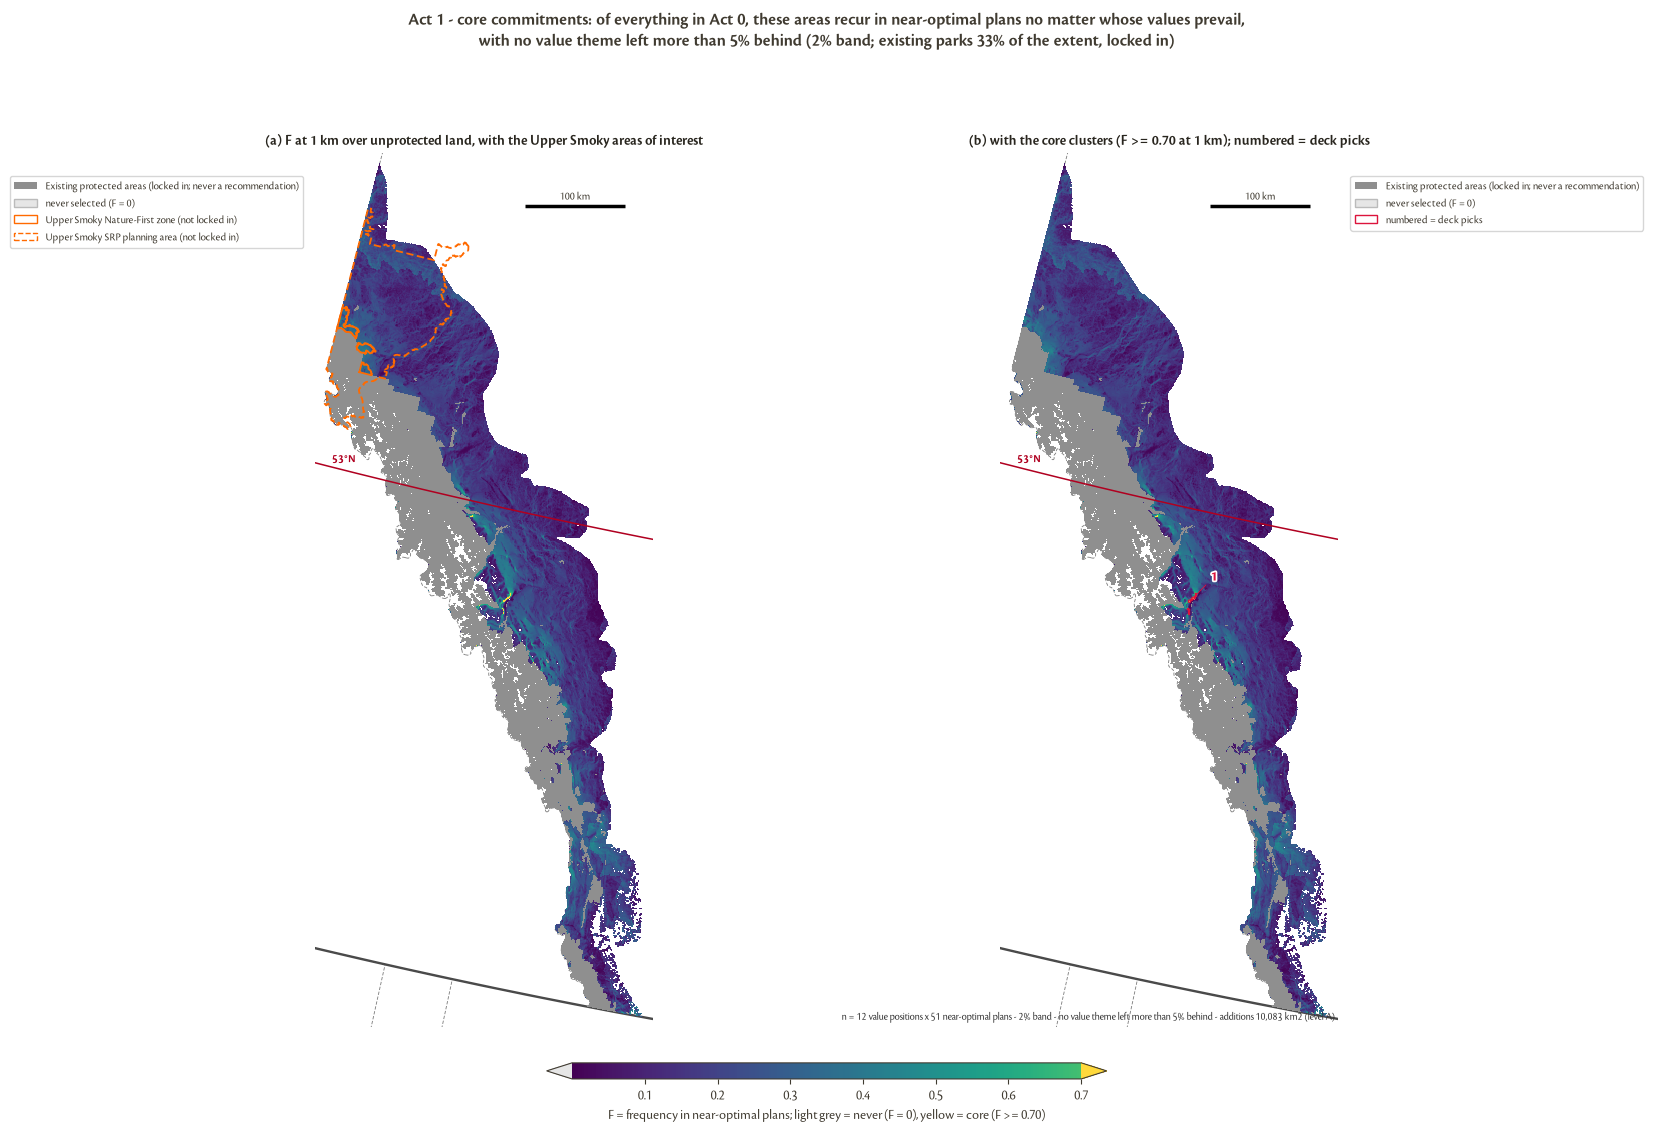

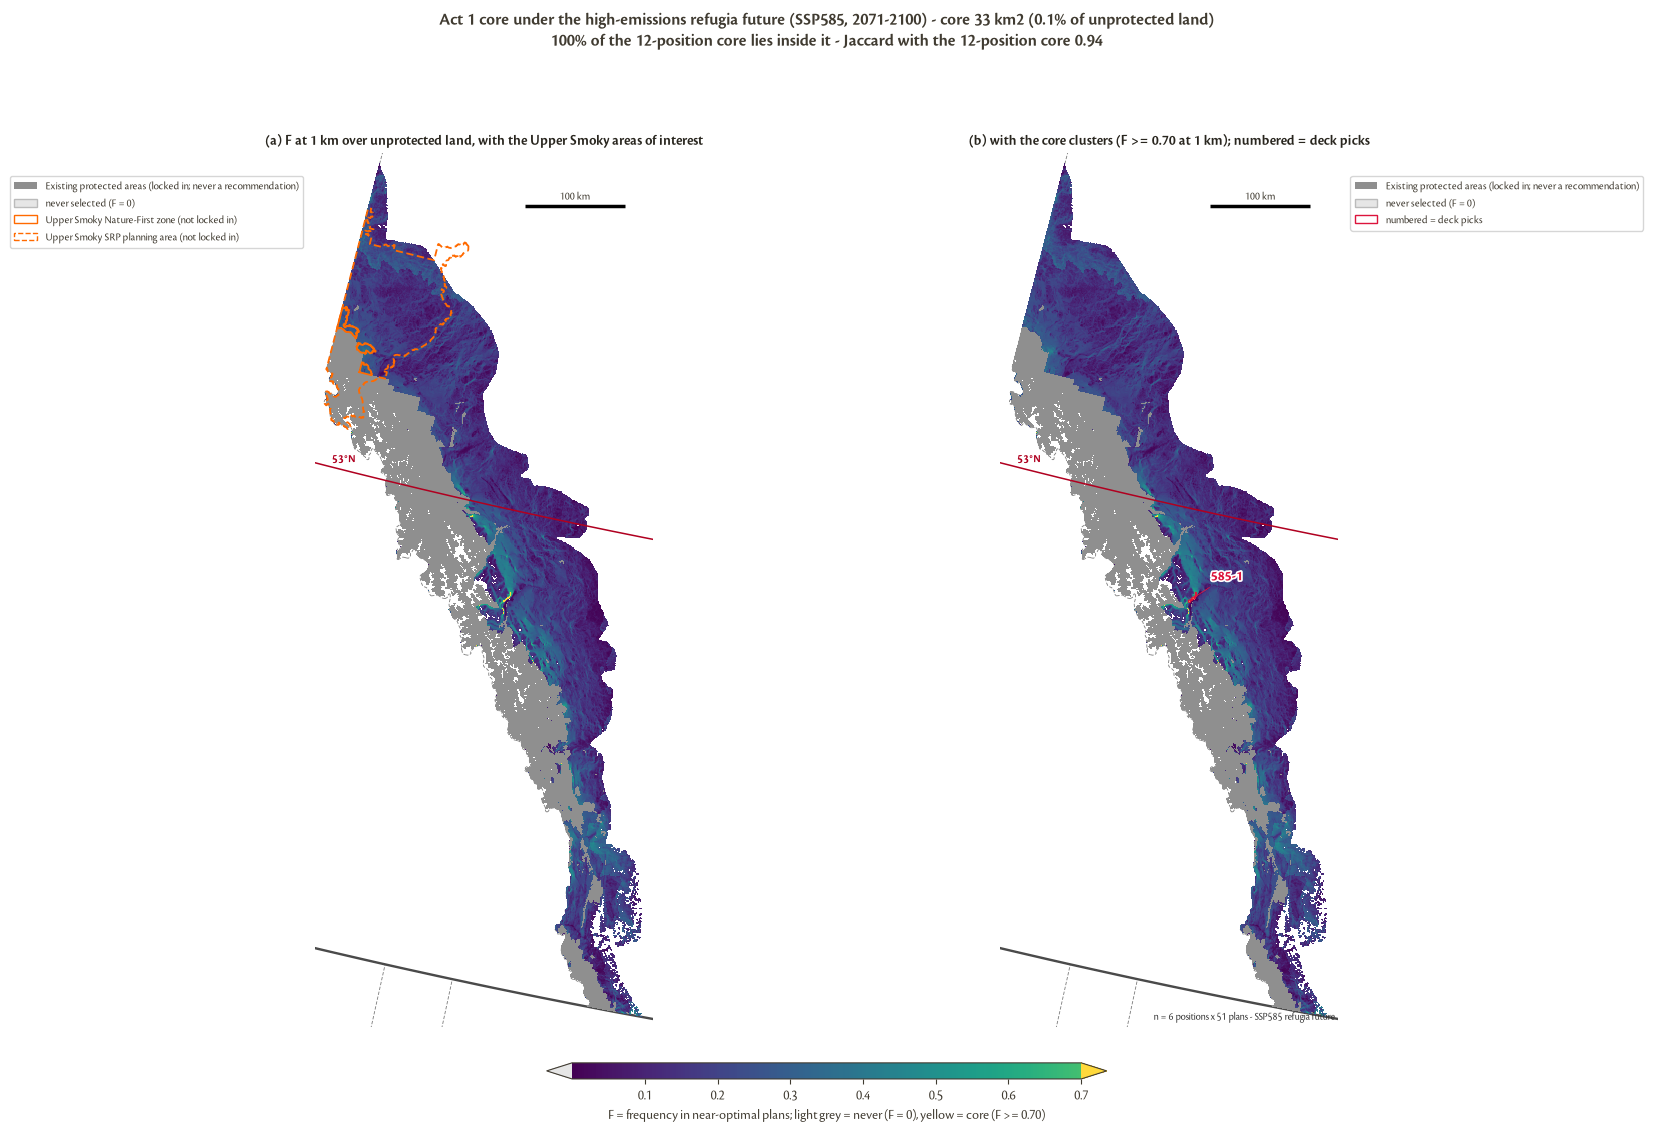

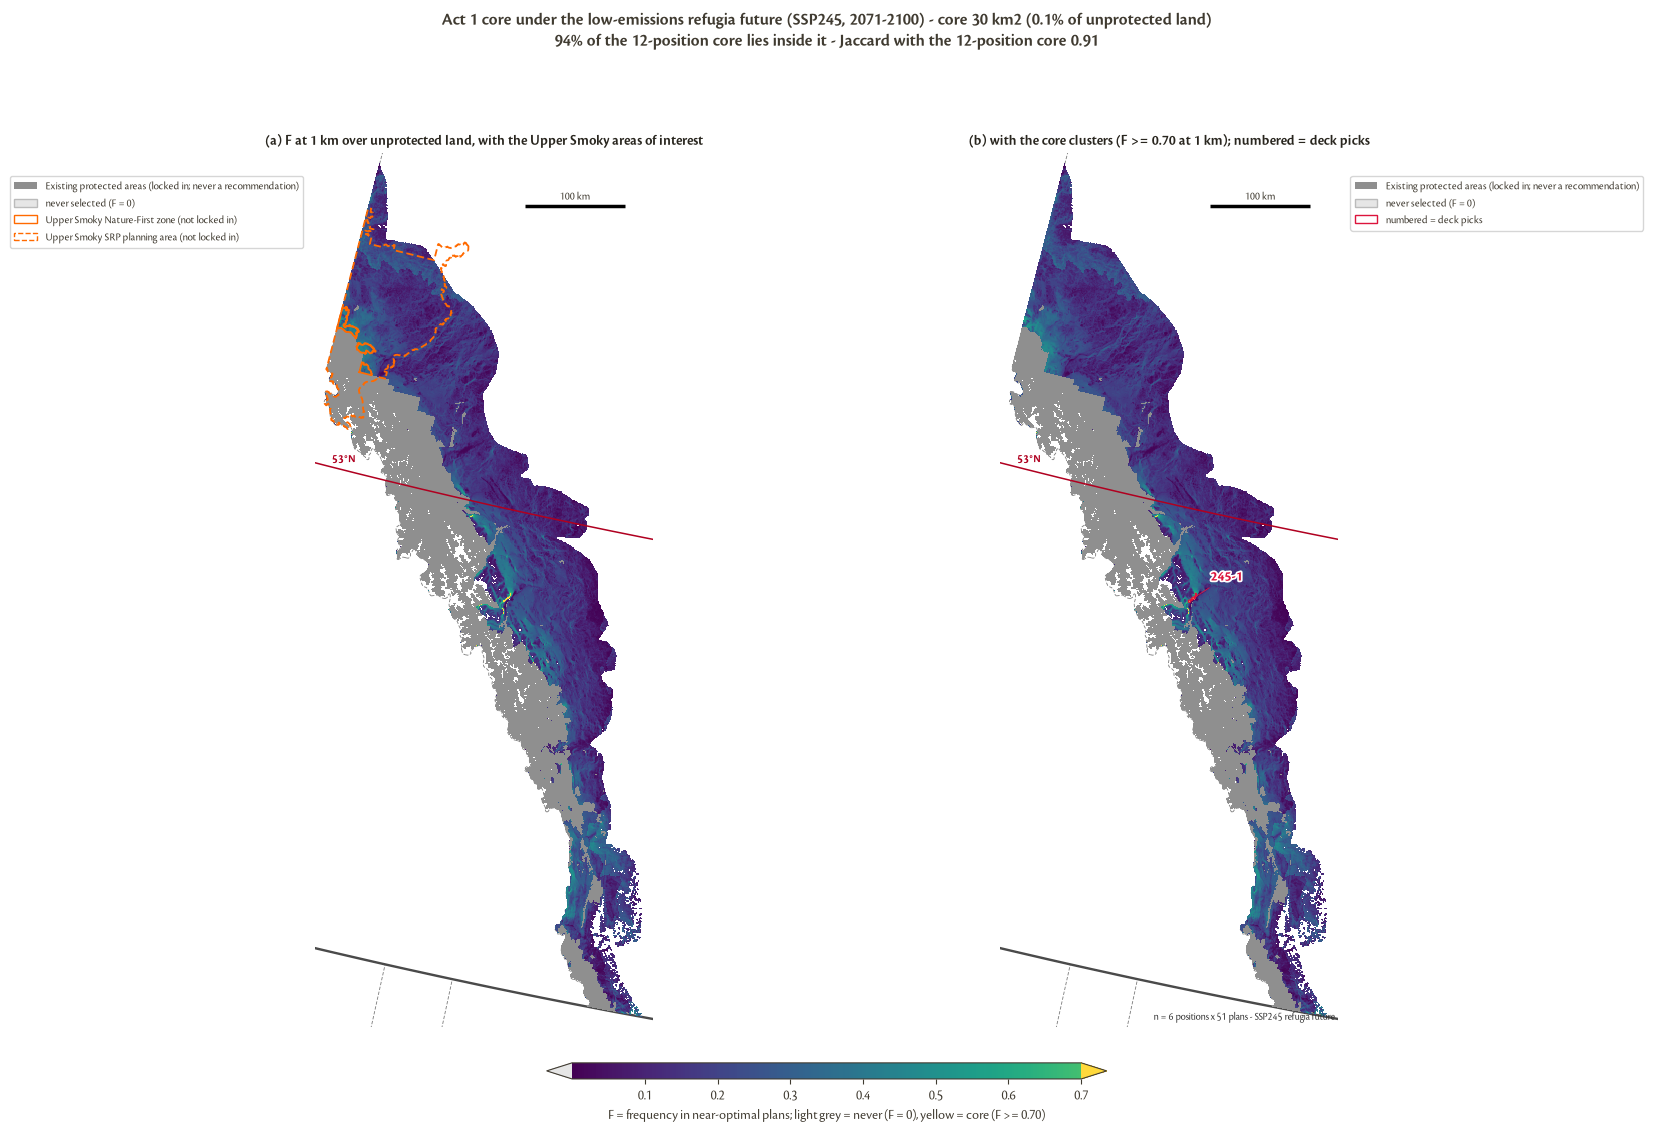

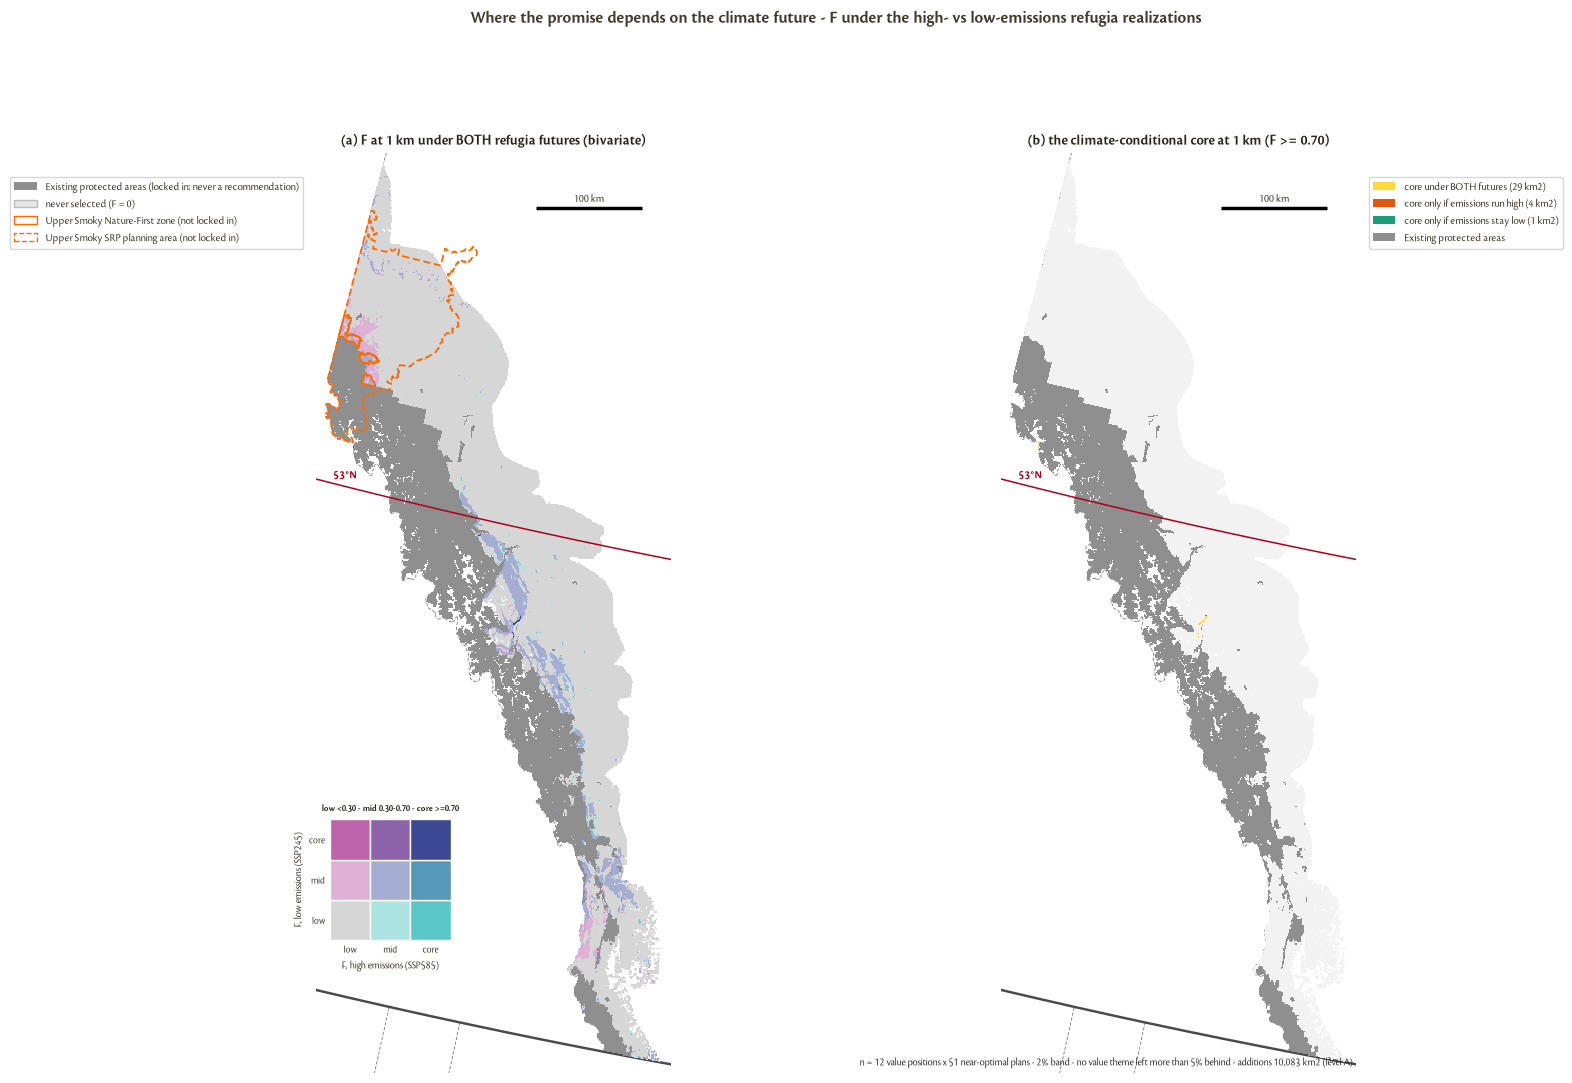

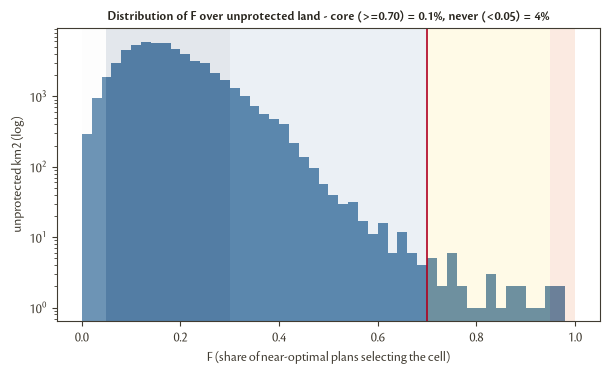

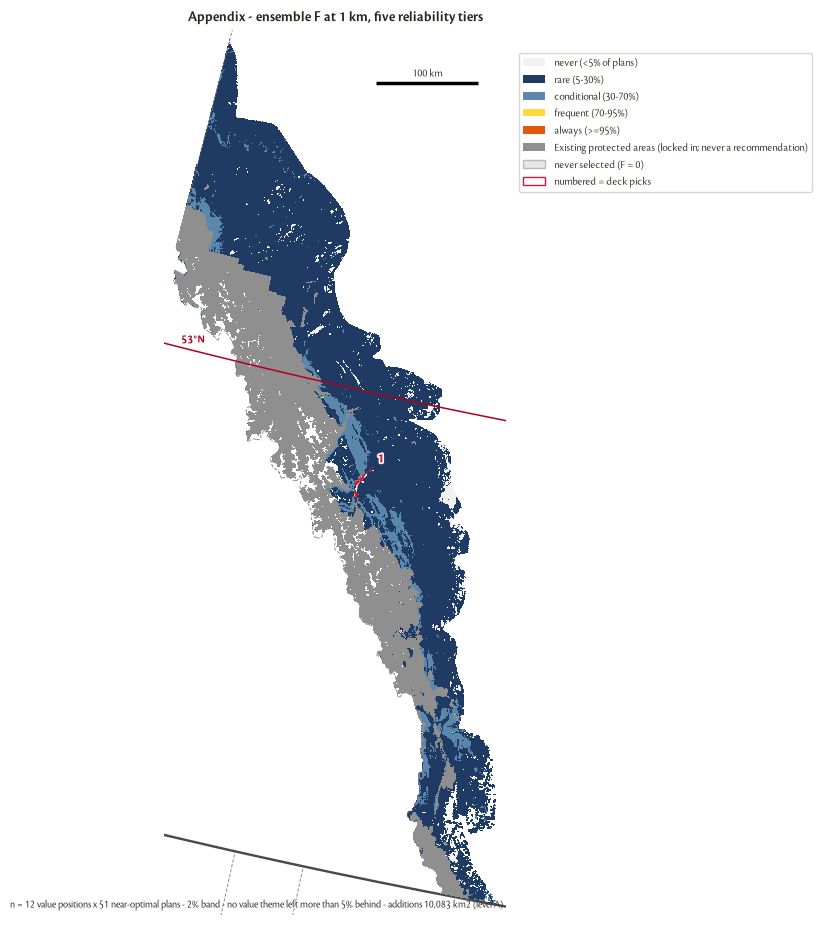

core tier (F >= 0.70): 31 km2


In [4]:
# ---- Act 1: the core -- the (a)/(b) pair at 1 km, AOIs on (a) (the IPCA analogue); clusters numbered north -> south -----------
ACT1_SENT = ("Act 1 - core commitments: of everything in Act 0, these areas recur in near-optimal plans no matter whose values prevail,\n"
             f"with no value theme left more than 5% behind ({BANDPCT}% band; existing parks {S['pa_pct_of_extent']:.0f}% of the extent, locked in)")
def act1_pair(F, layer, numbers, note_b, suptitle, fname):
    fig, axes = plt.subplots(1, 2, figsize=(14, 11.5)); fig.subplots_adjust(left=0.02, right=0.98, top=0.86, bottom=0.10, wspace=0.04)
    for ax, panel in zip(axes, ("a", "b")):
        draw_surface(ax, F); draw_pa(ax)
        if panel == "a": draw_aoi(ax)
        else: draw_clusters(ax, layer, numbers)
        finish(ax, "(a) F at 1 km over unprotected land, with the Upper Smoky areas of interest" if panel == "a"
               else "(b) with the core clusters (F >= 0.70 at 1 km); numbered = deck picks",
               BASE_HANDLES if panel == "b" else BASE_HANDLES[:2] + AOI_HANDLES, note=note_b if panel == "b" else "", legend_side="left" if panel == "a" else "right")
    colorbar(fig); fig.suptitle(suptitle, fontsize=12.5, y=0.985); fig.savefig(FIGD / fname, dpi=180, bbox_inches="tight"); plt.show()
act1_pair(Fg, "act1", picks_for("Act 1"), N_NOTE, ACT1_SENT, "act1_core_1km.png")
LEV_FIGS = {}
for lv in ("585", "245"):
    p_ = GEO / f"F_guarded_ssp{lv}.tif"
    if not p_.exists(): continue
    bl = S["by_level"][lv]
    act1_pair(rd(p_.name), f"act1_{lv}", picks_for(f"Act 1 ({lv})"), f"n = {bl['n']} positions x 51 plans - SSP{lv} refugia future",
              f"Act 1 core under the {'high' if lv == '585' else 'low'}-emissions refugia future (SSP{lv}, 2071-2100) - core {bl['core_km2']:,} km2 "
              f"({100 * bl['core_km2'] / G.n_disc:.1f}% of unprotected land)\n{bl['pct_of_12_inside']:.0f}% of the 12-position core lies inside it - "
              f"Jaccard with the 12-position core {bl['jaccard_vs_12']:.2f}", f"act1_core_ssp{lv}_1km.png")
    LEV_FIGS[lv] = FIGD / f"act1_core_ssp{lv}_1km.png"
# two-way climate map at 1 km: (a) bivariate F under both futures, (b) climate-conditional core
F5, F2 = rd("F_guarded_ssp585.tif"), rd("F_guarded_ssp245.tif")
BR = [0.30, dc.FREQ_THR]; cls = lambda v: np.digitize(v, BR)
BIV = np.array([["#d6d6d6", "#ace4e4", "#5ac8c8"], ["#dfb0d6", "#a5add3", "#5698b9"], ["#be64ac", "#8c62aa", "#3b4994"]])
i5, i2 = cls(F5), cls(F2); code_ = (i2 * 3 + i5).astype(np.float32); code_[~G.disc] = np.nan
never = G.disc & (F5 == 0) & (F2 == 0)
biv_cmap = ListedColormap(list(BIV.ravel())); B2 = dc.to_grid(G, code_); B2[dc.to_grid(G, never, fill=False, dtype=bool)] = np.nan
fig, axes = plt.subplots(1, 2, figsize=(14, 11.5)); fig.subplots_adjust(left=0.02, right=0.98, top=0.86, bottom=0.06, wspace=0.04)
ax = axes[0]; ax.imshow(B2, cmap=biv_cmap, norm=BoundaryNorm(np.arange(-0.5, 9.5, 1), 9), interpolation="nearest", zorder=0.5)
ax.imshow(np.where(dc.to_grid(G, never, fill=False, dtype=bool), 1.0, np.nan), cmap=ListedColormap([NEVER_COLOR]), interpolation="nearest", zorder=0.6)
draw_pa(ax); draw_aoi(ax); finish(ax, "(a) F at 1 km under BOTH refugia futures (bivariate)", BASE_HANDLES[:2] + AOI_HANDLES, note="", legend_side="left")
leg = ax.inset_axes([0.04, 0.04, 0.34, 0.34])
for r in range(3):
    for c in range(3): leg.add_patch(plt.Rectangle((c, r), 1, 1, facecolor=BIV[r, c], edgecolor="white"))
leg.set_xlim(0, 3); leg.set_ylim(0, 3); leg.set_aspect("equal"); leg.set_xticks([0.5, 1.5, 2.5]); leg.set_xticklabels(["low", "mid", "core"], fontsize=7)
leg.set_yticks([0.5, 1.5, 2.5]); leg.set_yticklabels(["low", "mid", "core"], fontsize=7); leg.set_xlabel("F, high emissions (SSP585)", fontsize=7.5); leg.set_ylabel("F, low emissions (SSP245)", fontsize=7.5)
leg.set_title("low <0.30 - mid 0.30-0.70 - core >=0.70", fontsize=6.5); leg.tick_params(length=0)
for sp in leg.spines.values(): sp.set_visible(False)
c5, c2 = (F5 >= dc.FREQ_THR) & G.disc, (F2 >= dc.FREQ_THR) & G.disc
cat = np.zeros(G.n_pu, np.uint8); cat[c5 & ~c2] = 1; cat[c2 & ~c5] = 2; cat[c5 & c2] = 3
C2 = dc.to_grid(G, cat.astype(np.float32)); C2[~G.pu] = np.nan
ax = axes[1]; ax.imshow(C2, cmap=ListedColormap(["#f2f2f2", "#e6550d", "#1b9e77", "#ffd93b"]), norm=BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], 4), interpolation="nearest", zorder=0.5); draw_pa(ax)
finish(ax, "(b) the climate-conditional core at 1 km (F >= 0.70)",
       [Patch(facecolor="#ffd93b", label=f"core under BOTH futures ({int((c5 & c2).sum()):,} km2)"), Patch(facecolor="#e6550d", label=f"core only if emissions run high ({int((c5 & ~c2).sum()):,} km2)"),
        Patch(facecolor="#1b9e77", label=f"core only if emissions stay low ({int((c2 & ~c5).sum()):,} km2)"), Patch(facecolor=PA_COLOR, label="Existing protected areas")], note=N_NOTE)
fig.suptitle("Where the promise depends on the climate future - F under the high- vs low-emissions refugia realizations", fontsize=12.5, y=0.985)
fig.savefig(FIGD / "act1_two_way_climate.png", dpi=180, bbox_inches="tight"); plt.show()
# histogram + tiers appendix
fig, ax = plt.subplots(figsize=(7, 3.8)); ax.hist(Fg[G.disc], bins=50, range=(0, 1), color="#5b87ad"); ax.axvline(dc.FREQ_THR, color="#b00020", lw=1.2)
for name, lo, hi in dc.BANDS: ax.axvspan(lo, min(hi, 1), color=BAND_COLORS[[b_[0] for b_ in dc.BANDS].index(name)], alpha=0.12, lw=0)
ax.set_yscale("log"); ax.set_xlabel("F (share of near-optimal plans selecting the cell)"); ax.set_ylabel("unprotected km2 (log)")
ax.set_title(f"Distribution of F over unprotected land - core (>=0.70) = {S['tier_area_pct_disc']['core']:.1f}%, never (<0.05) = {100 * (Fg[G.disc] < dc.NEVER_THR).mean():.0f}%", fontsize=9.5)
fig.savefig(FIGD / "act1_F_histogram.png", dpi=200, bbox_inches="tight"); plt.show()
fig, ax = plt.subplots(figsize=(7.5, 11.5)); ax.imshow(Fg2, cmap=ListedColormap(BAND_COLORS), norm=BoundaryNorm(BAND_BOUNDS, 5), interpolation="nearest"); draw_pa(ax); draw_clusters(ax, "act1", picks_for("Act 1"))
finish(ax, "Appendix - ensemble F at 1 km, five reliability tiers", [Patch(facecolor=c, label=n) for c, n in zip(BAND_COLORS, BAND_NAMES)] + BASE_HANDLES)
fig.savefig(FIGD / "act1_core_1km_tiers.png", dpi=200, bbox_inches="tight"); plt.show()
print(f"core tier (F >= 0.70): {S['frequent_km2']['guarded']:,} km2")
# the Act 1 maps are SHARED assets (director_plot.core_map_F / core_map_clusters): the Alberta frame + one inset on the key cluster
if KEY is not None:
    dp.core_map_F(C, FIGD / "act1_core_F_1km.png")
    dp.core_map_clusters(C, FIGD / "act1_core_clusters_1km.png")
else:
    print("no core picks -- the shared Act 1 asset maps are skipped (the (a)/(b) pair above stands)")


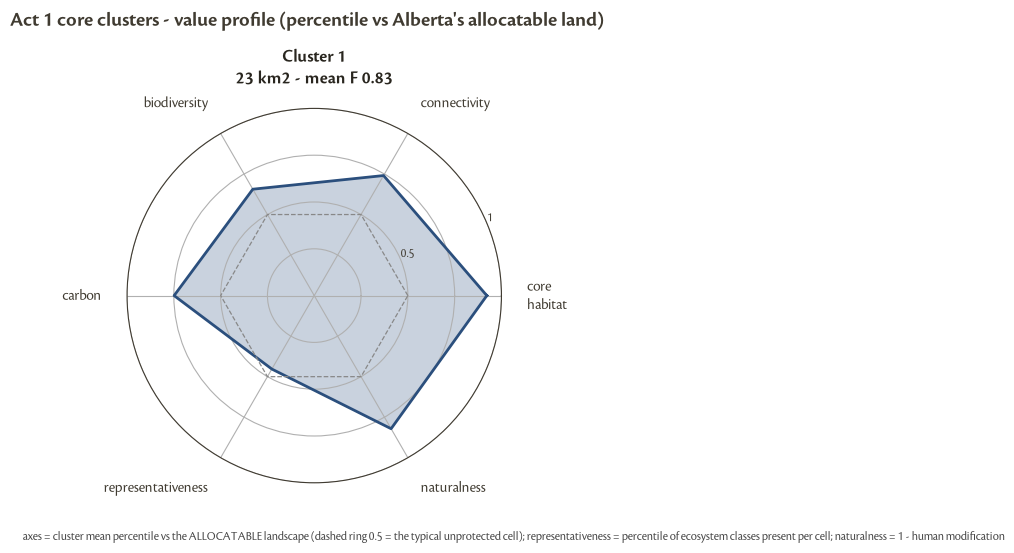

In [5]:
# ---- Act 1 star grid + cluster locators (shared assets: director_plot.core_stars / cluster_locators; "Cluster N", adequacy-pin caption) ----
A1 = TD1[(TD1.act == "Act 1") & TD1.number.notna() & (TD1.number != "")].copy(); A1["number"] = A1.number.astype(int); A1 = A1.sort_values("number")
if len(A1):
    dp.core_stars(C, FIGD / "act1_star_grid.png", "Act 1 core clusters - value profile (percentile vs Alberta's allocatable land)")
    dp.cluster_locators(C, FIGD / "act1_cluster_locators.png")
else:
    print("no core clusters at the applied band -- no Act 1 star grid / locators (the core is the finding: see td2_bands / the summary map)")


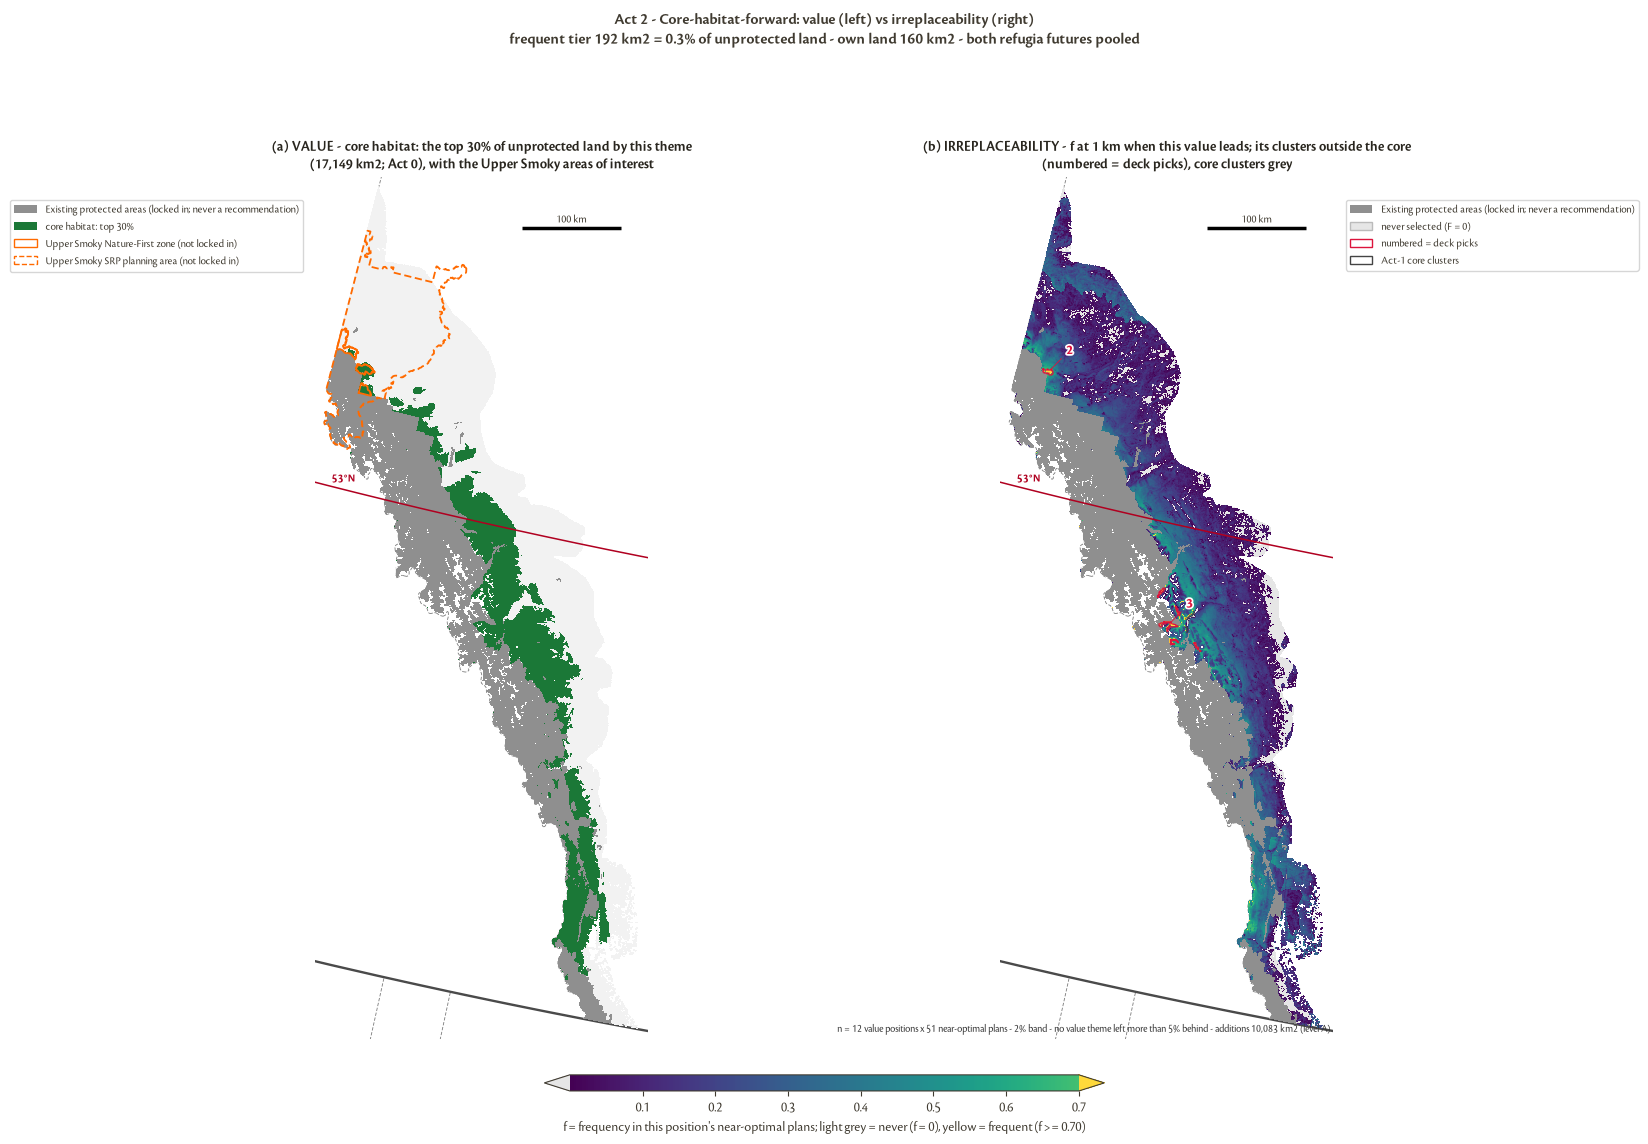

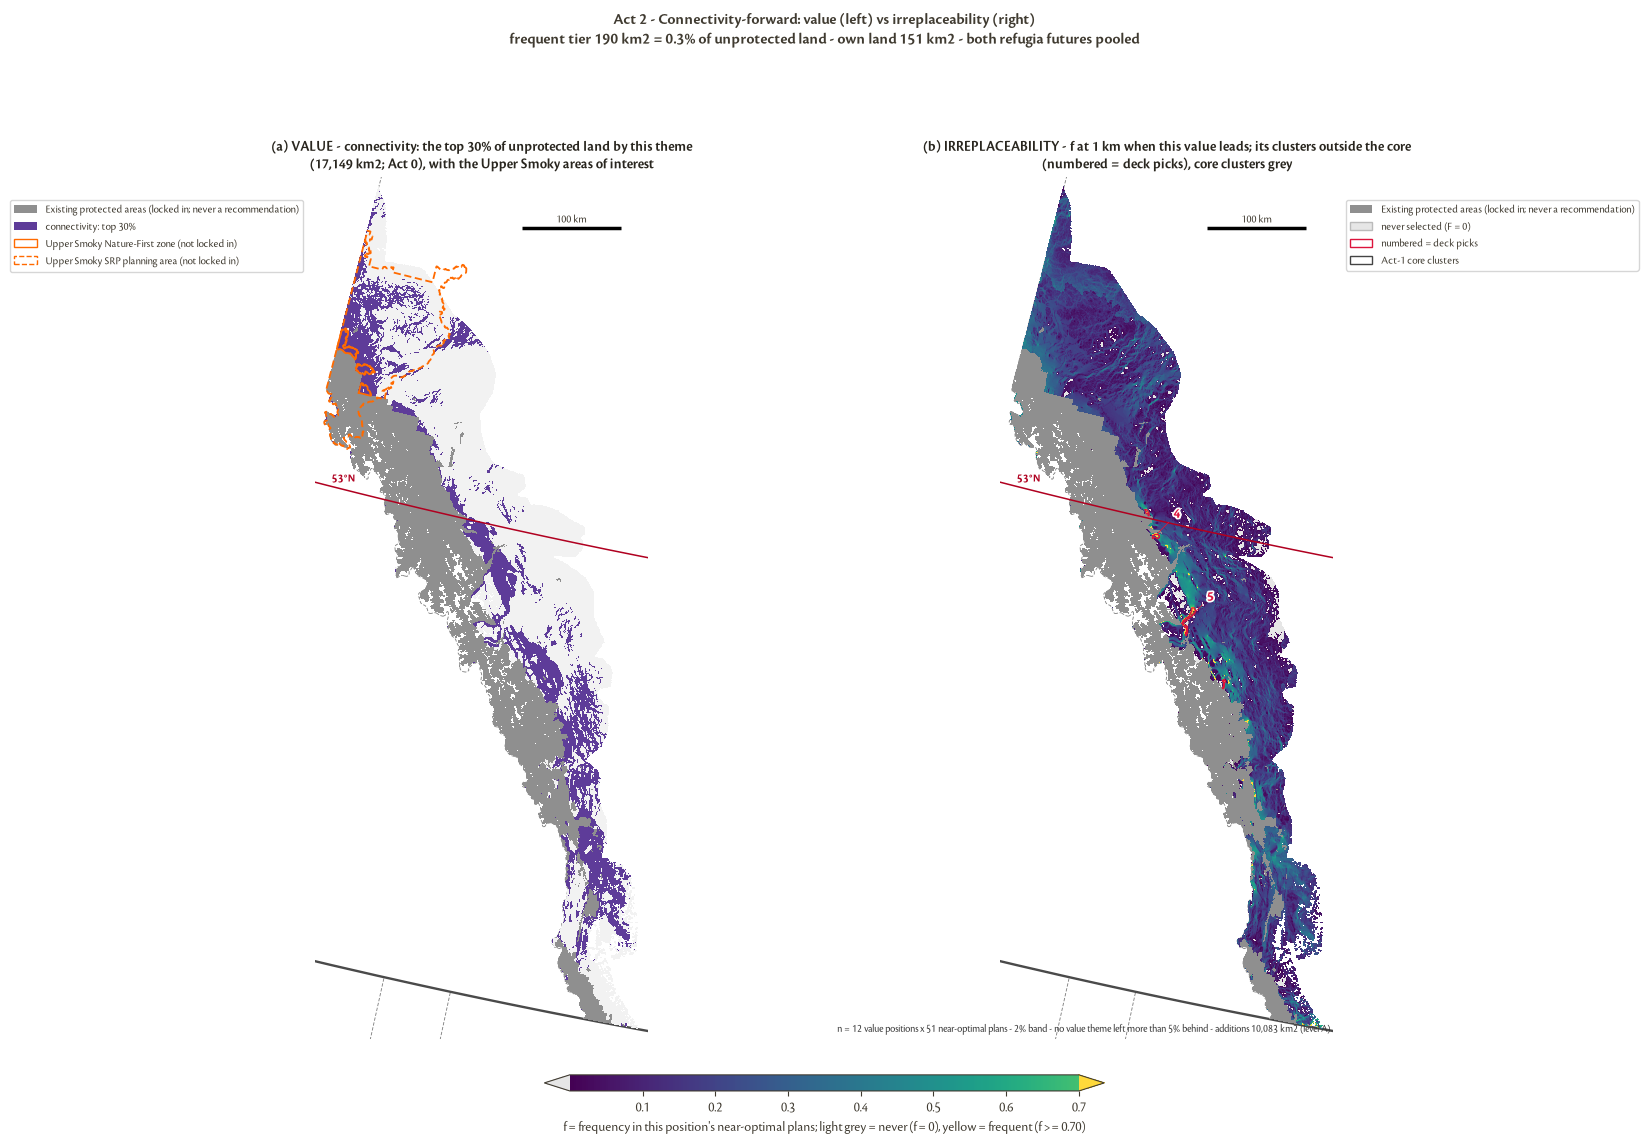

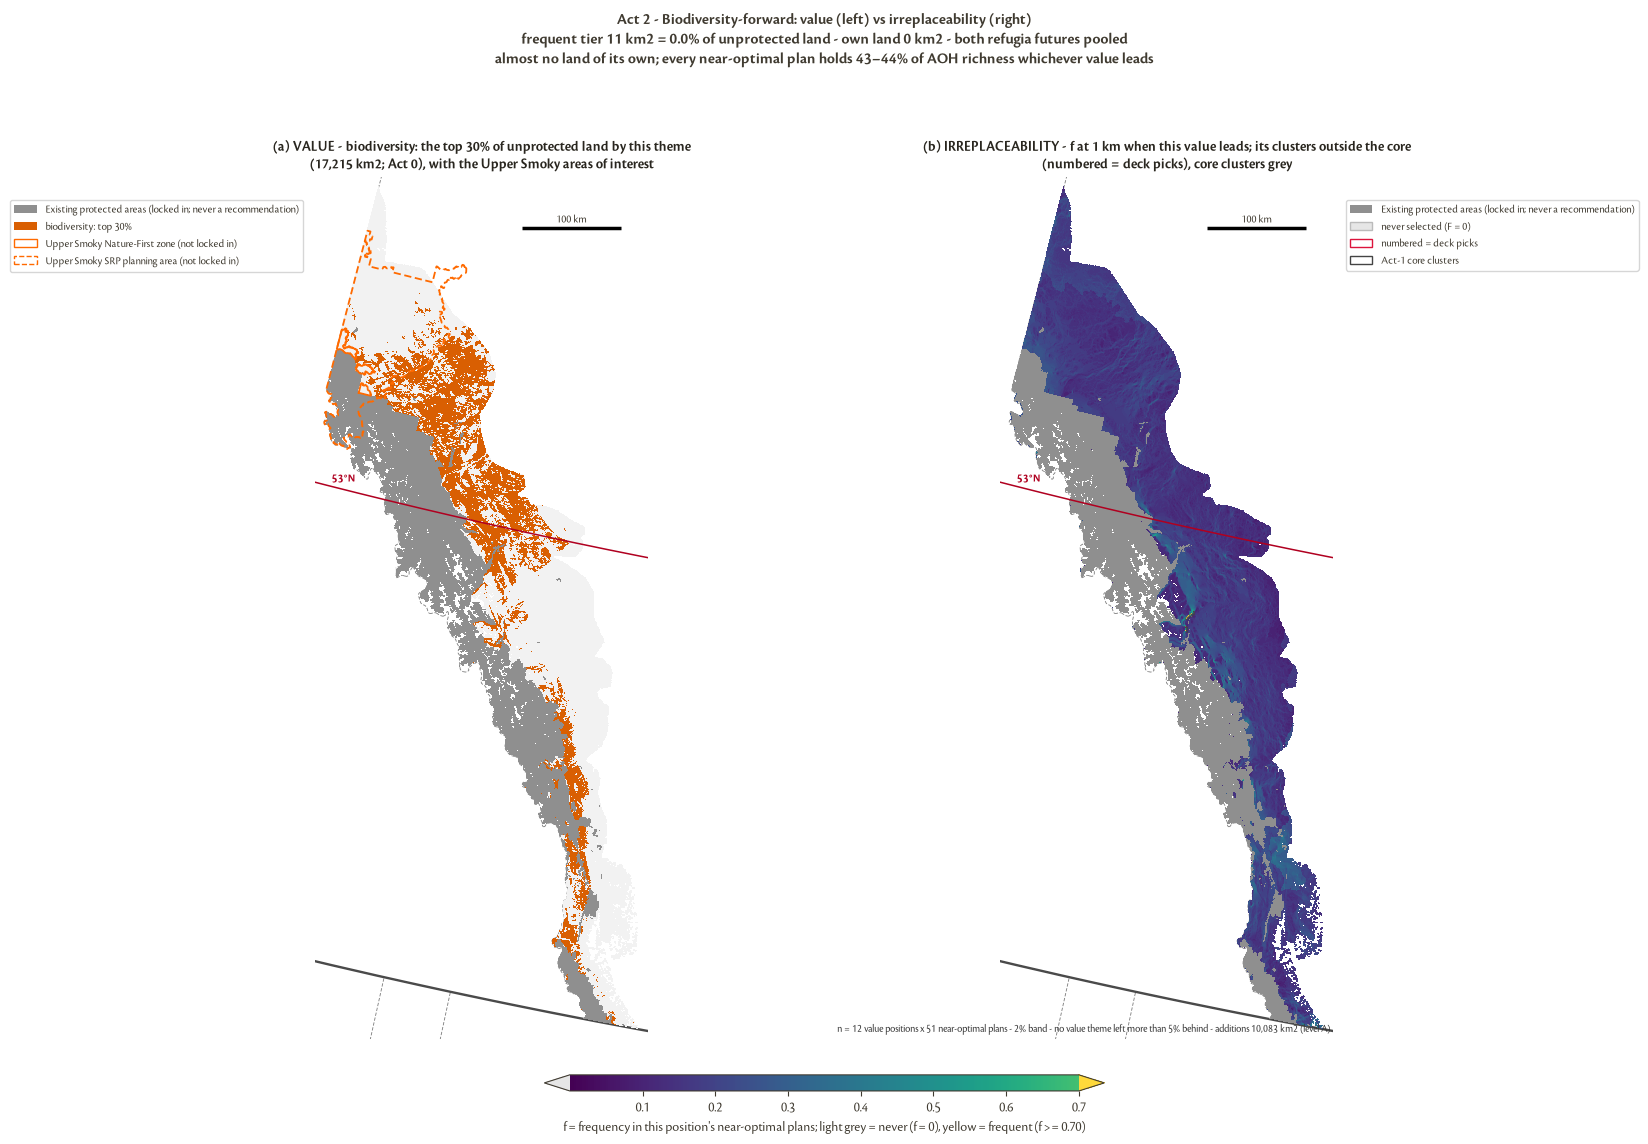

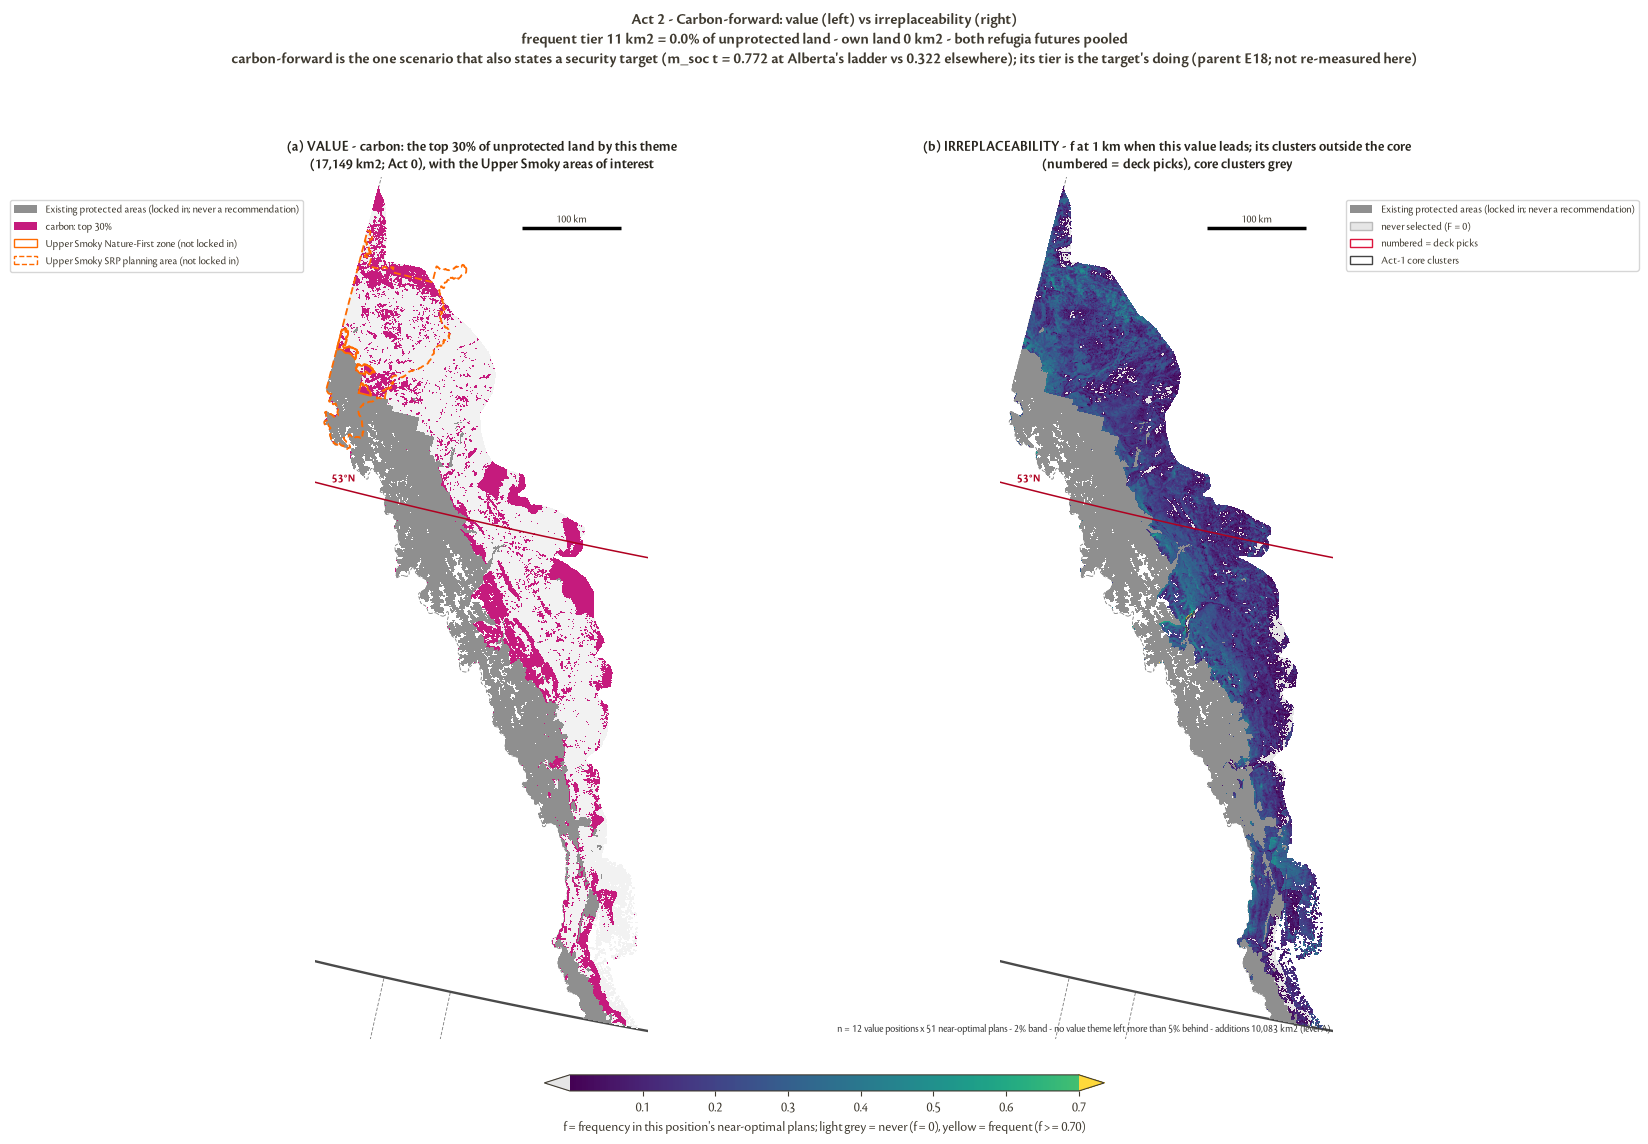

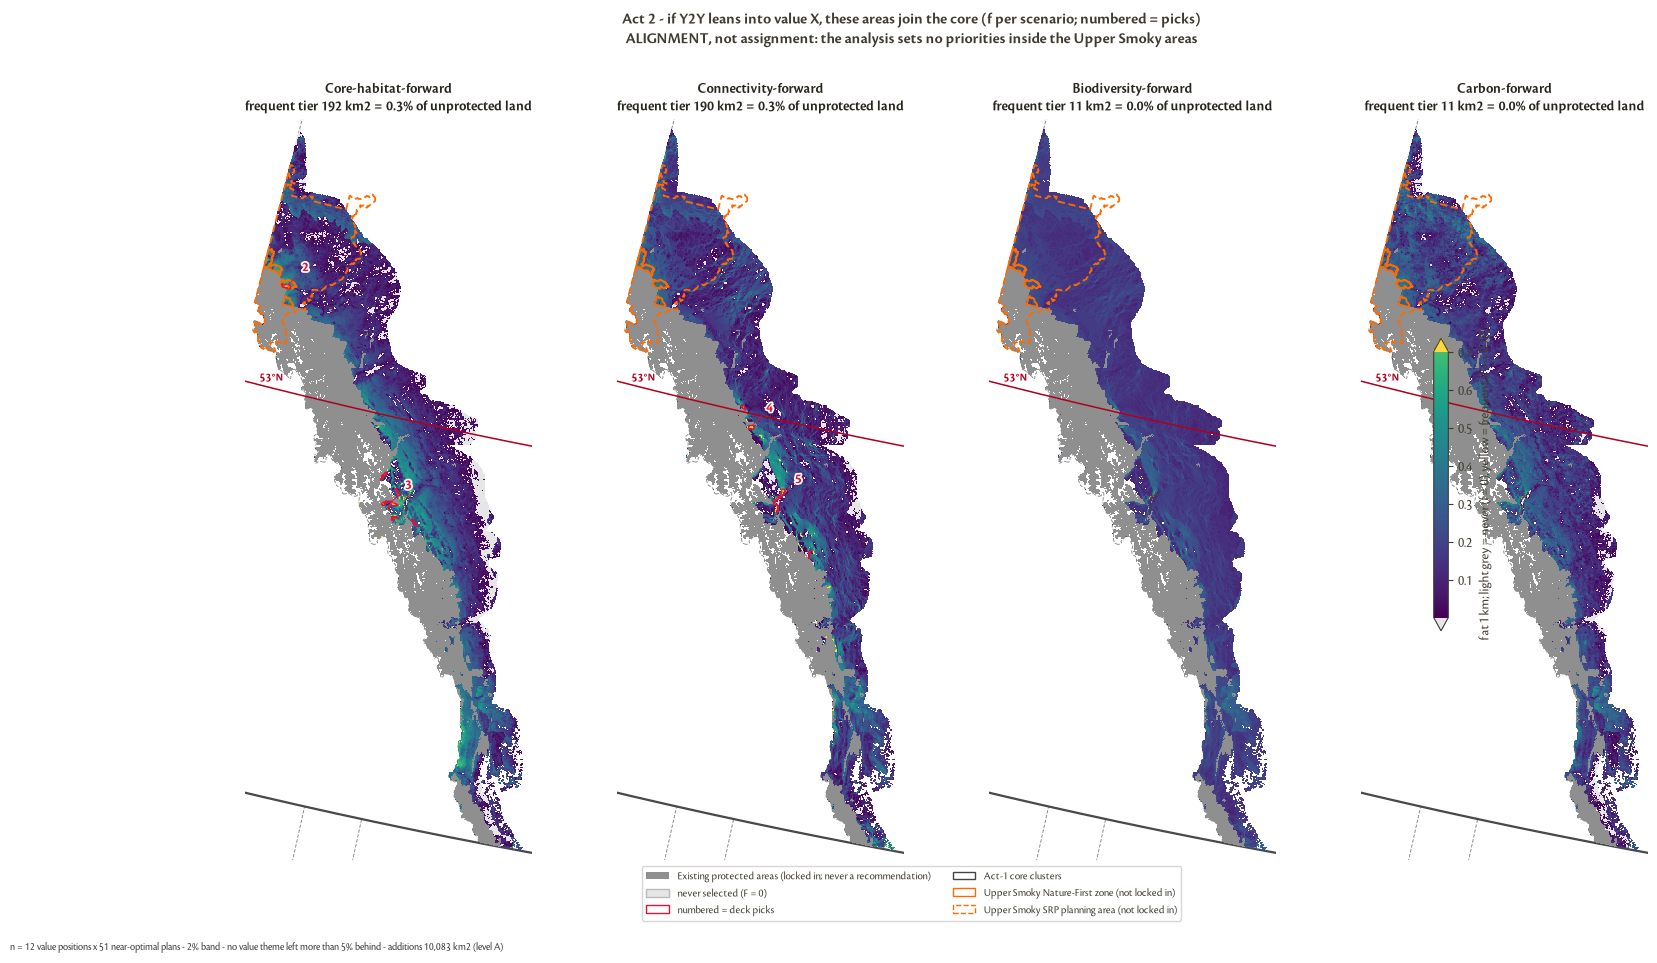

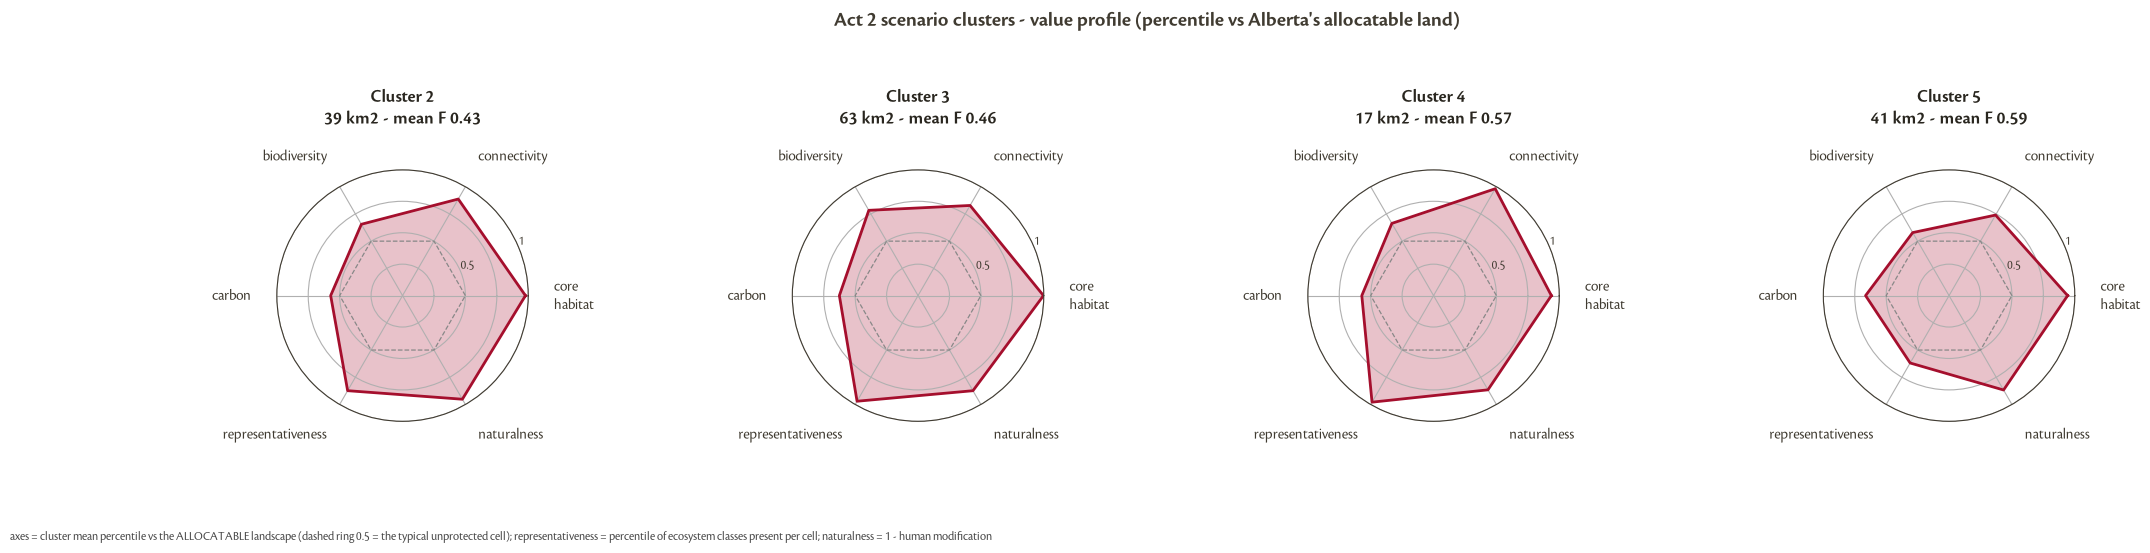

In [6]:
# ---- Act 2: per-scenario PAIRING -- the theme's VALUE (left, Act 0, at 1 km) beside its IRREPLACEABILITY (right) --------------
keys = [k for k in POOL if k.split("@")[0] in dc.ACT2_SCENARIOS]
ACT3_FIGS = {}
own = S["act2_owner_km2"]
for key in keys:
    sid = key.split("@")[0]; theme = dc.THEME_OF_SCENARIO[sid]; lab_ = dc.SCENARIO_LABEL[sid]; f = POOL[key]
    freq = int(((f >= dc.FREQ_THR) & G.disc).sum())
    rec = next(r for r in S["pooling"] if r["scenario"] == sid)
    note = "both refugia futures pooled" if rec["decision"].startswith("POOLED") else ("single level" if rec["levels"] == 1 else f"level {key.split('@')[1]} shown separately")
    fig, axes = plt.subplots(1, 2, figsize=(14, 11.5)); fig.subplots_adjust(left=0.02, right=0.98, top=0.85, bottom=0.10, wspace=0.04)
    ax = axes[0]
    g2 = dc.to_grid(G, np.where(G.disc, VAL[theme].astype(np.float32), np.nan))
    ax.imshow(np.where(g2 > 0, 1.0, np.nan), cmap=ListedColormap([TCOL[theme]]), interpolation="nearest", zorder=0.5)
    ax.imshow(np.where(g2 == 0, 1.0, np.nan), cmap=ListedColormap(["#f2f2f2"]), interpolation="nearest", zorder=0.4)
    draw_pa(ax); draw_aoi(ax)
    finish(ax, f"(a) VALUE - {theme}: the top 30% of unprotected land by this theme\n({SV['footprint_km2'][theme]:,} km2; Act 0), with the Upper Smoky areas of interest",
           BASE_HANDLES[:1] + [Patch(facecolor=TCOL[theme], label=f"{theme}: top 30%")] + AOI_HANDLES, note="", legend_side="left")
    ax = axes[1]; draw_surface(ax, f); draw_pa(ax)
    draw_clusters(ax, "act1", {}, color="#444444", lw=0.5); draw_clusters(ax, f"act2_{key}", picks_for("Act 2", key))
    for _, r in TD1[(TD1.act == "Act 2") & (TD1.driving == key) & TD1.number.notna() & (TD1.number != "")].iterrows():
        for col, lab2 in (("pct_in_NFZ", "the Nature-First zone"), ("pct_in_SRP_area", "the Upper Smoky planning area")):
            if r[col] >= 5:
                rr = PICKS[PICKS.number.astype(str) == str(r.number)].iloc[0]; x_, y_ = dc.xy_to_px(G, *T_LL.transform(rr.lon, rr.lat))
                ax.annotate(f"{r[col]:.0f}% inside\n{lab2}", xy=(x_, y_), xytext=(x_ - 90, y_ + 60), fontsize=7, color=AOI_COLOR, path_effects=halo, zorder=6,
                            arrowprops=dict(arrowstyle="->", color=AOI_COLOR, lw=0.7)); break
    finish(ax, "(b) IRREPLACEABILITY - f at 1 km when this value leads; its clusters outside the core\n(numbered = deck picks), core clusters grey",
           BASE_HANDLES + [Patch(facecolor="none", edgecolor="#444444", label="Act-1 core clusters")], note=N_NOTE)
    colorbar(fig, "f = frequency in this position's near-optimal plans; light grey = never (f = 0), yellow = frequent (f >= 0.70)")
    sub = f"frequent tier {freq:,} km2 = {100 * freq / G.n_disc:.1f}% of unprotected land - own land {own[lab_]:,} km2 - {note}"
    extra = ""
    if sid == "s3":
        extra = "\n" + dc.BIODIV_FINDING.format(lo=100 * BIO["min"], hi=100 * BIO["max"])
    if sid == "s4":
        extra = ("\ncarbon-forward is the one scenario that also states a security target (m_soc t = 0.772 at Alberta's ladder vs 0.322 elsewhere); "
                 "its tier is the target's doing (parent E18; not re-measured here)")
    fig.suptitle(f"Act 2 - {lab_}: value (left) vs irreplaceability (right)\n{sub}{extra}", fontsize=11.5, y=0.995)
    fn = FIGD / f"act2_{key.replace('@', '_')}_1km.png"; fig.savefig(fn, dpi=180, bbox_inches="tight"); plt.show(); ACT3_FIGS[key] = fn
n = len(keys); fig, axes = plt.subplots(1, max(n, 1), figsize=(4.6 * max(n, 1), 9.5), squeeze=False)
for ax, key in zip(axes[0], keys):
    sid = key.split("@")[0]; draw_surface(ax, POOL[key]); draw_pa(ax); draw_aoi(ax); draw_clusters(ax, "act1", {}, color="#444444", lw=0.5); draw_clusters(ax, f"act2_{key}", picks_for("Act 2", key))
    freq = int(((POOL[key] >= dc.FREQ_THR) & G.disc).sum())
    finish(ax, f"{dc.SCENARIO_LABEL[sid]}\nfrequent tier {freq:,} km2 = {100 * freq / G.n_disc:.1f}% of unprotected land", None, note="", scale=False)
fig.legend(handles=BASE_HANDLES + [Patch(facecolor="none", edgecolor="#444444", label="Act-1 core clusters")] + AOI_HANDLES, loc="lower center", ncol=2, fontsize=8, frameon=True, bbox_to_anchor=(0.5, 0.03))
fig.colorbar(ScalarMappable(norm=FNORM, cmap=FCMAP), ax=axes[0].tolist(), shrink=0.4, extend="both", pad=0.01, label="f at 1 km; light grey = never (f = 0), yellow = frequent (f >= 0.70)")
fig.suptitle("Act 2 - if Y2Y leans into value X, these areas join the core (f per scenario; numbered = picks)\nALIGNMENT, not assignment: the analysis sets no priorities inside the Upper Smoky areas", fontsize=11.5, y=0.995)
fig.text(0.01, 0.005, N_NOTE, fontsize=7.5, color="#333333"); fig.subplots_adjust(bottom=0.1)
fig.savefig(FIGD / "act2_scenarios_overview.png", dpi=180, bbox_inches="tight"); plt.show()
A2 = TD1[(TD1.act == "Act 2") & TD1.number.notna() & (TD1.number != "")].copy(); A2["number"] = A2.number.astype(int); A2 = A2.sort_values("number")
if len(A2):
    dp.scenario_stars(C, FIGD / "act2_star_grid.png", "Act 2 scenario clusters - value profile (percentile vs Alberta's allocatable land)")


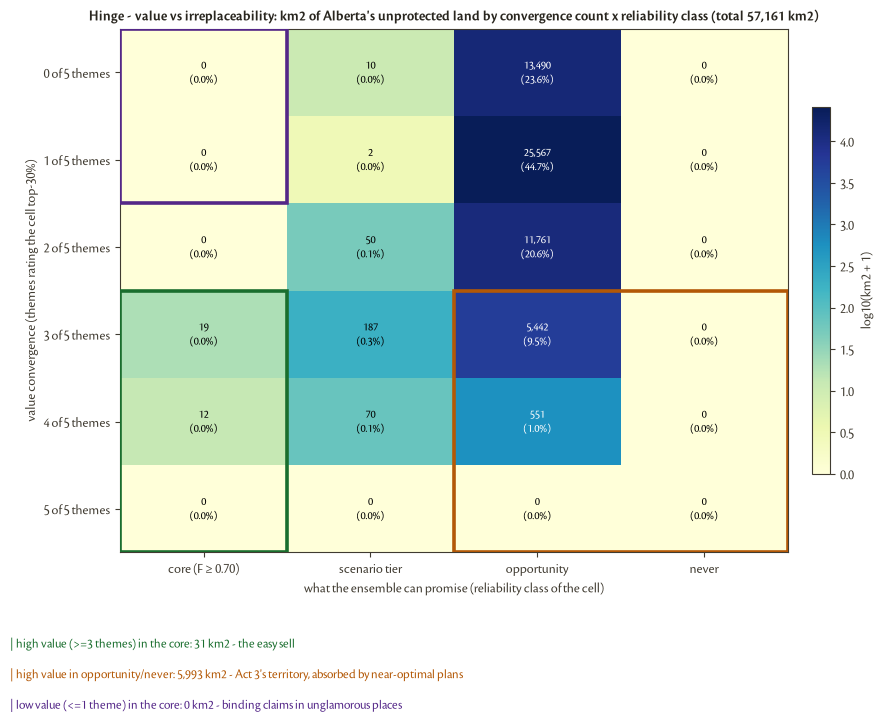

In [7]:
# ---- hinge (between Acts 2 and 3): value-convergence count x reliability class, km2 -----------------------------------------
XTv = XT.values.astype(float); tot = XTv.sum()
fig, ax = plt.subplots(figsize=(10.5, 6.8))
im = ax.imshow(np.log10(XTv + 1), cmap="YlGnBu", aspect="auto")
ax.set_xticks(range(XT.shape[1])); ax.set_xticklabels(XT.columns, fontsize=10)
ax.set_yticks(range(XT.shape[0])); ax.set_yticklabels(XT.index, fontsize=10)
lmax = np.log10(XTv.max() + 1)
for i in range(XT.shape[0]):
    for j in range(XT.shape[1]):
        v = XTv[i, j]
        ax.text(j, i, f"{v:,.0f}\n({100 * v / tot:.1f}%)", ha="center", va="center", fontsize=8.5, color="white" if np.log10(v + 1) > 0.62 * lmax else "black")
ax.set_xlabel("what the ensemble can promise (reliability class of the cell)"); ax.set_ylabel("value convergence (themes rating the cell top-30%)")
ax.set_title(f"Hinge - value vs irreplaceability: km2 of Alberta's unprotected land by convergence count x reliability class (total {tot:,.0f} km2)", fontsize=10.5)
hi_rows = XTv[3:, :].sum(0)
from matplotlib.patches import Rectangle
corners = [((-0.5, 2.5), 1, 3, "#1a6e2e", f"high value (>=3 themes) in the core: {hi_rows[0]:,.0f} km2 - the easy sell"),
           ((1.5, 2.5), 2, 3, "#b35806", f"high value in opportunity/never: {hi_rows[2] + hi_rows[3]:,.0f} km2 - Act 3's territory, absorbed by near-optimal plans"),
           ((-0.5, -0.5), 1, 2, "#542788", f"low value (<=1 theme) in the core: {XTv[:2, 0].sum():,.0f} km2 - binding claims in unglamorous places")]
for (x0, y0), w, h, col, _ in corners:
    ax.add_patch(Rectangle((x0, y0), w, h, fill=False, edgecolor=col, lw=2.6, zorder=5))
for k, (_, _, _, col, txt) in enumerate(corners):
    fig.text(0.02, -0.03 - 0.045 * k, "| " + txt, fontsize=9.5, color=col, ha="left")
fig.colorbar(im, ax=ax, shrink=0.7, pad=0.03, label="log10(km2 + 1)")
fig.savefig(FIGD / "hinge_convergence_x_F.png", dpi=200, bbox_inches="tight"); plt.show()


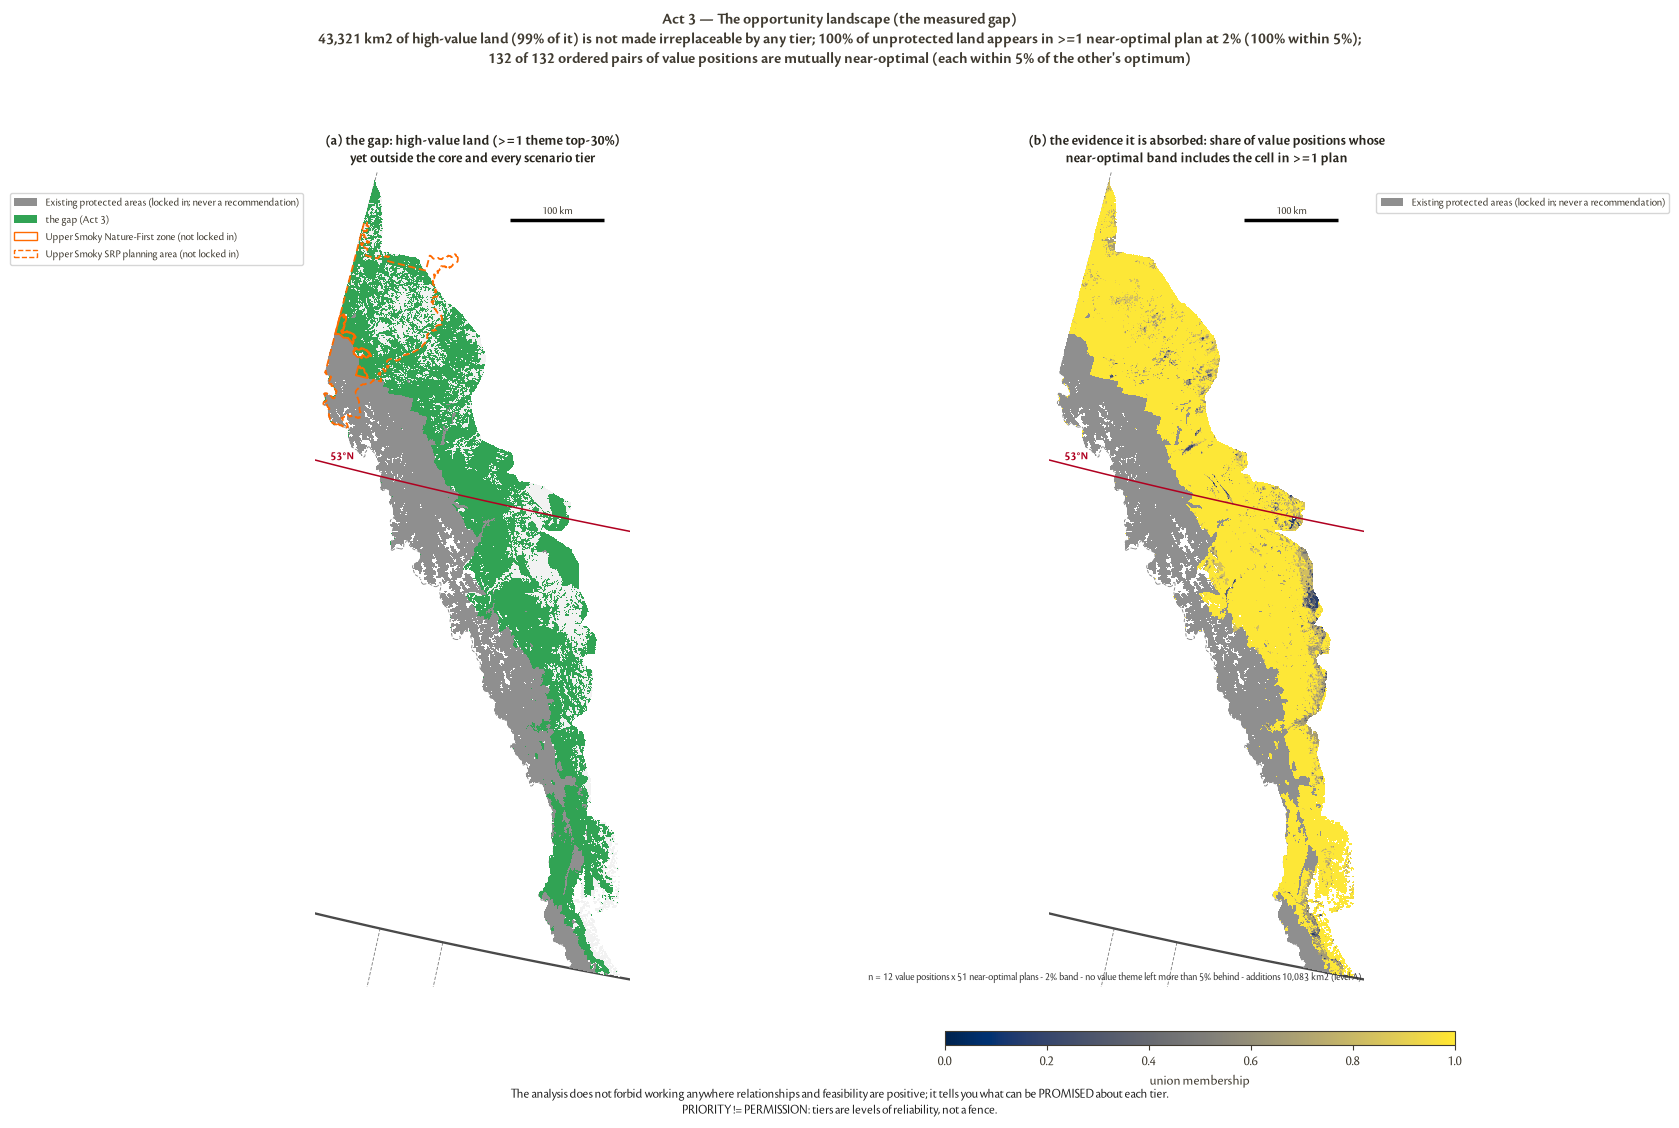

In [8]:
# ---- Act 3: the opportunity landscape = value minus irreplaceability, backed by union membership (1 km) ---------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 11.5)); fig.subplots_adjust(left=0.02, right=0.98, top=0.85, bottom=0.14, wspace=0.04)
ax = axes[0]
g2 = dc.to_grid(G, np.where(G.disc, (GAP > 0).astype(np.float32), np.nan))
ax.imshow(np.where(g2 > 0, 1.0, np.nan), cmap=ListedColormap(["#31a354"]), interpolation="nearest", zorder=0.5)
ax.imshow(np.where(g2 == 0, 1.0, np.nan), cmap=ListedColormap(["#f2f2f2"]), interpolation="nearest", zorder=0.4)
draw_pa(ax); draw_aoi(ax)
finish(ax, "(a) the gap: high-value land (>=1 theme top-30%)\nyet outside the core and every scenario tier", BASE_HANDLES[:1] + [Patch(facecolor="#31a354", label="the gap (Act 3)")] + AOI_HANDLES, note="", legend_side="left")
ax = axes[1]; draw_surface(ax, Ug, cmap=plt.get_cmap("cividis"), norm=Normalize(0, 1)); draw_pa(ax)
finish(ax, "(b) the evidence it is absorbed: share of value positions whose\nnear-optimal band includes the cell in >=1 plan", BASE_HANDLES[:1])
cax2 = fig.add_axes([0.57, 0.09, 0.34, 0.012])
fig.colorbar(ScalarMappable(norm=Normalize(0, 1), cmap="cividis"), cax=cax2, orientation="horizontal", label="union membership")
e11 = S["e11_pairs_in_band"]
fig.suptitle(f"{dc.ACT_TITLE['act3']}\n{SV['gap_km2']:,} km2 of high-value land ({SV['gap_pct_of_high_value']:.0f}% of it) is not made irreplaceable by any tier; "
             f"{S['ever_in_band_pct']['guarded']:.0f}% of unprotected land appears in >=1 near-optimal plan at {BANDPCT}% ({S['ever_in_5pct_band_pct']:.0f}% within 5%);\n"
             f"{e11[0]} of {e11[1]} ordered pairs of value positions are mutually near-optimal (each within 5% of the other's optimum)", fontsize=11.5, y=0.99)
fig.text(0.5, 0.03, "The analysis does not forbid working anywhere relationships and feasibility are positive; it tells you what can be PROMISED about each tier.\n"
         "PRIORITY != PERMISSION: tiers are levels of reliability, not a fence.", ha="center", fontsize=9.5, color="#222222")
fig.savefig(FIGD / "act3_opportunity.png", dpi=180, bbox_inches="tight"); plt.show()


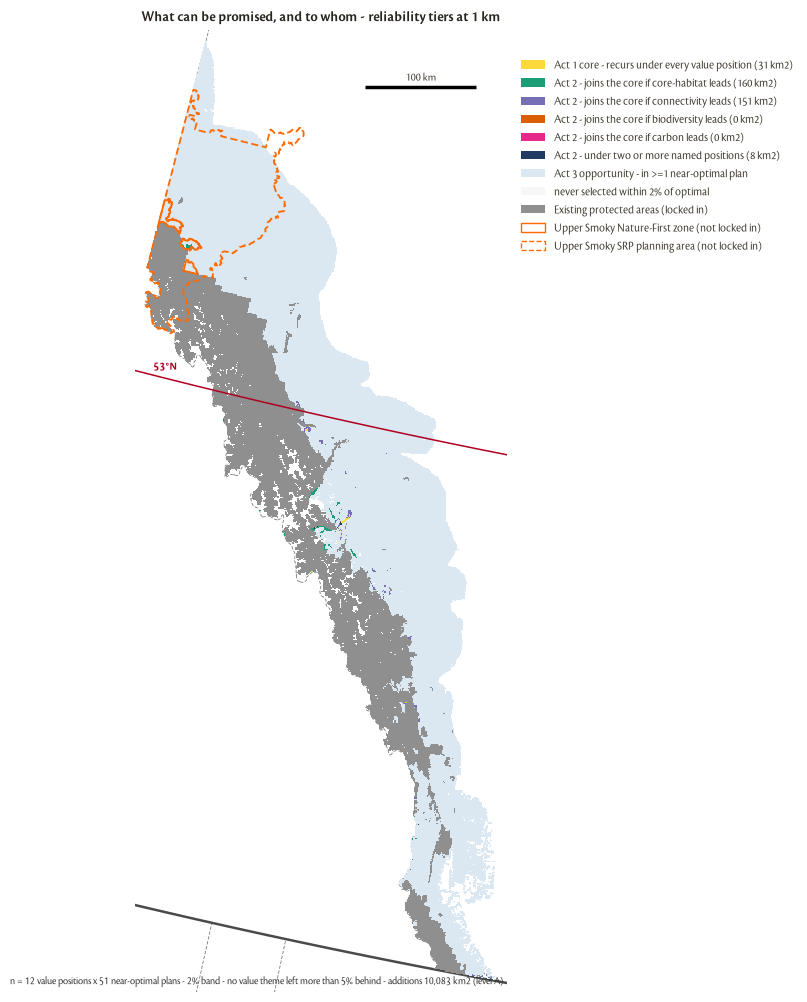

In [9]:
# ---- THE SUMMARY MAP: tiers at 1 km with Act 3 split by the scenario that earns the cell (acts 0-3) --------------------
with rasterio.open(GEO / "act2_owner.tif") as src: OWN = src.read(1)
SC_COL = {"s1": "#1b9e77", "s2": "#7570b3", "s3": "#d95f02", "s4": "#e7298a"}
cls_ = np.full(G.shape, np.nan, np.float32); cls_[G.pu] = 0; cls_[TIERS == 1] = 1
for i, sid in enumerate(dc.ACT2_SCENARIOS, 1): cls_[(TIERS == 2) & (OWN == i)] = 1 + i
cls_[(TIERS == 2) & (OWN == 5)] = 6; cls_[TIERS == 3] = 7; cls_[~G.pu] = np.nan
colors = ["#f7f7f7", "#dbe7f1"] + [SC_COL[s] for s in dc.ACT2_SCENARIOS] + ["#1f3a63", "#ffd93b"]
fig, ax = plt.subplots(figsize=(9, 12.5)); ax.imshow(cls_, cmap=ListedColormap(colors), norm=BoundaryNorm(np.arange(-0.5, 8.5, 1), 8), interpolation="nearest", zorder=0.5); draw_pa(ax); draw_aoi(ax)
own = S["act2_owner_km2"]
handles = [Patch(facecolor="#ffd93b", label=f"Act 1 core - recurs under every value position ({S['frequent_km2']['guarded']:,} km2)")]
for sid in dc.ACT2_SCENARIOS:
    lab_ = dc.SCENARIO_LABEL[sid]; handles.append(Patch(facecolor=SC_COL[sid], label=f"Act 2 - joins the core if {lab_.lower().replace('-forward', '')} leads ({own[lab_]:,} km2)"))
handles += [Patch(facecolor="#1f3a63", label=f"Act 2 - under two or more named positions ({own['2+ scenarios']:,} km2)"), Patch(facecolor="#dbe7f1", label="Act 3 opportunity - in >=1 near-optimal plan"),
            Patch(facecolor="#f7f7f7", label=f"never selected within {BANDPCT}% of optimal"), Patch(facecolor=PA_COLOR, label="Existing protected areas (locked in)")] + AOI_HANDLES
finish(ax, "What can be promised, and to whom - reliability tiers at 1 km", None)
ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.01, 0.98), fontsize=8.5, frameon=False)
fig.savefig(FIGD / "summary_tiers_1km.png", dpi=200, bbox_inches="tight"); plt.show()

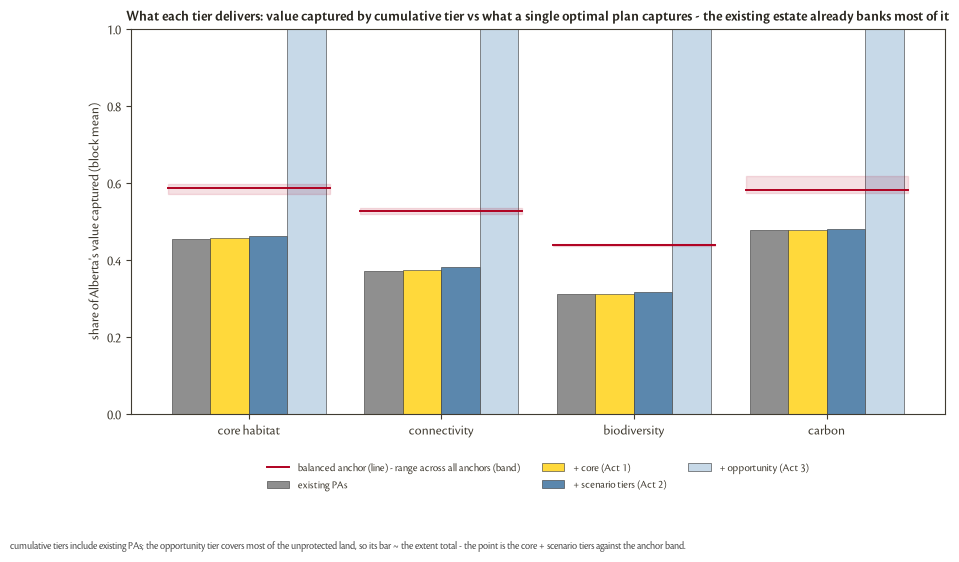

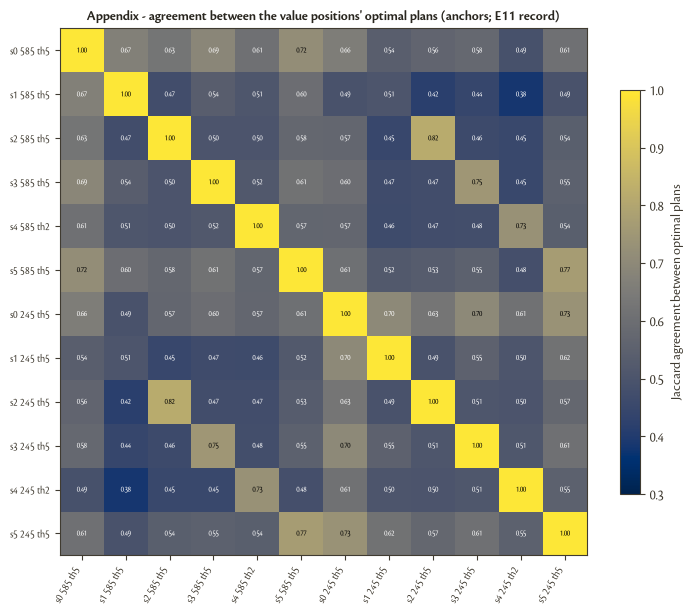

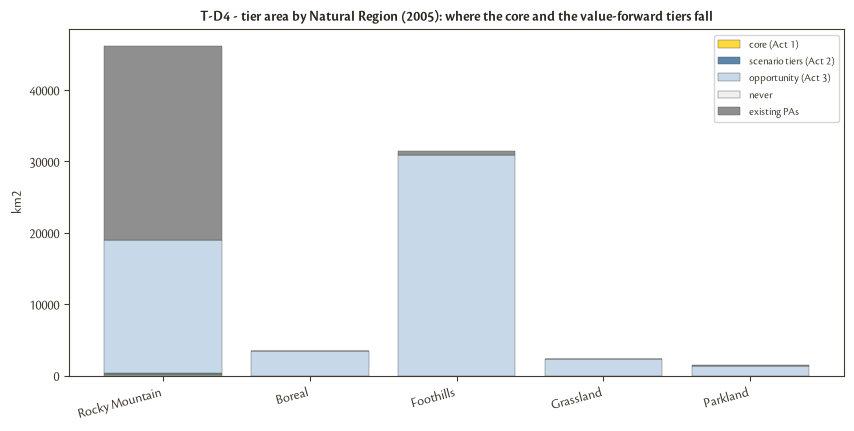

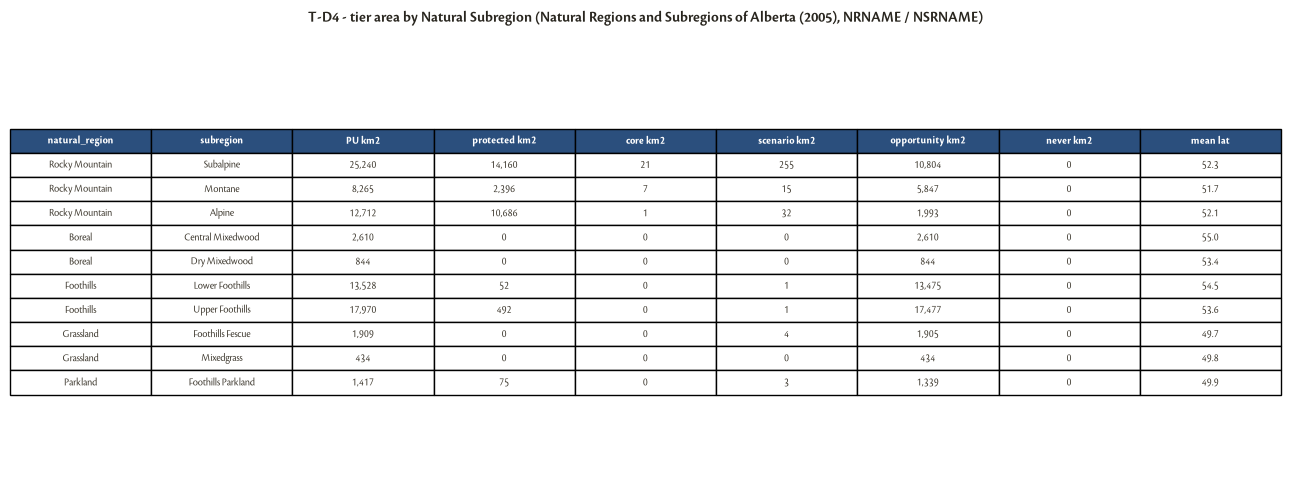

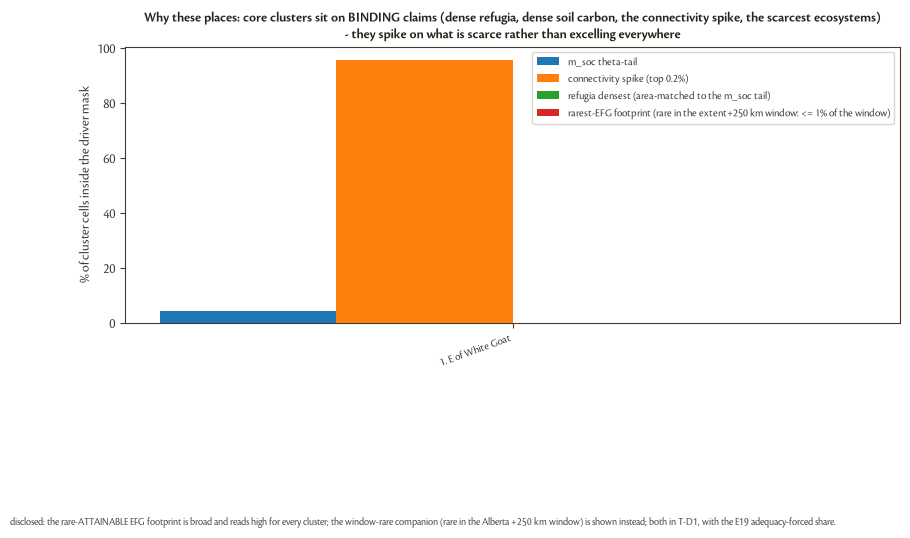

In [10]:
# ---- tier achievement, agreement matrix, T-D4 render, why these places ---------------------------------------------------
TA = pd.read_csv(TAB / "tier_achievement.csv"); TA_ref = pd.read_csv(TAB / "tier_achievement_reference.csv", index_col=0)
tiers_order = ["existing PAs", "+ Act 1 core", "+ Act 2 scenario tiers", "+ Act 3 opportunity"]
piv = TA[TA.feature == "BLOCK"].pivot(index="tier", columns="block", values="capture").reindex(tiers_order)
blocks = ["core_habitat", "connectivity", "biodiversity", "carbon"]
fig, ax = plt.subplots(figsize=(10.5, 5)); x = np.arange(len(blocks)); w = 0.2; tc = ["#8f8f8f", "#ffd93b", "#5b87ad", "#c7d9e8"]
TIER_LABEL = {"existing PAs": "existing PAs", "+ Act 1 core": "+ core (Act 1)", "+ Act 2 scenario tiers": "+ scenario tiers (Act 2)", "+ Act 3 opportunity": "+ opportunity (Act 3)"}
for i, tr_ in enumerate(tiers_order): ax.bar(x + (i - 1.5) * w, piv.loc[tr_, blocks].values, w, color=tc[i], label=TIER_LABEL[tr_], edgecolor="#333333", lw=0.4)
for j, bl in enumerate(blocks):
    ax.plot([x[j] - 0.42, x[j] + 0.42], [TA_ref.loc[bl, "s0"]] * 2, color="#b00020", lw=1.4); ax.fill_between([x[j] - 0.42, x[j] + 0.42], TA_ref.loc[bl, "anchor_min"], TA_ref.loc[bl, "anchor_max"], color="#b00020", alpha=0.12)
ax.set_xticks(x); ax.set_xticklabels([b_.replace("_", " ") for b_ in blocks]); ax.set_ylabel("share of Alberta's value captured (block mean)"); ax.set_ylim(0, 1)
ax.plot([], [], color="#b00020", lw=1.4, label="balanced anchor (line) - range across all anchors (band)"); ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False)
ax.set_title("What each tier delivers: value captured by cumulative tier vs what a single optimal plan captures - the existing estate already banks most of it", fontsize=10.5)
fig.text(0.01, -0.16, "cumulative tiers include existing PAs; the opportunity tier covers most of the unprotected land, so its bar ~ the extent total - the point is the core + scenario tiers against the anchor band.", fontsize=7.5, color="#444444")
fig.savefig(FIGD / "tier_achievement.png", dpi=200, bbox_inches="tight"); plt.show()
J = pd.read_csv(config.ab_paths().analysis / "tables" / "E11_anchor_jaccard.csv", index_col=0).loc[list(MAN.formulation_id), list(MAN.formulation_id)]
fig, ax = plt.subplots(figsize=(8.5, 7.5)); im = ax.imshow(J.values, cmap="cividis", vmin=0.3, vmax=1)
lab_ = [c.replace("_theta", " th").replace("_ssp", " ") for c in J.columns]
ax.set_xticks(range(len(J))); ax.set_xticklabels(lab_, rotation=60, ha="right", fontsize=7.5); ax.set_yticks(range(len(J))); ax.set_yticklabels(lab_, fontsize=7.5)
for i in range(len(J)):
    for j in range(len(J)): ax.text(j, i, f"{J.values[i, j]:.2f}", ha="center", va="center", fontsize=5.5, color="white" if J.values[i, j] < 0.7 else "black")
fig.colorbar(im, ax=ax, shrink=0.7, label="Jaccard agreement between optimal plans"); ax.set_title("Appendix - agreement between the value positions' optimal plans (anchors; E11 record)", fontsize=10)
fig.savefig(FIGD / "agreement_matrix.png", dpi=200, bbox_inches="tight"); plt.show()
TD4r = pd.read_csv(TAB / "T-D4_natural_regions.csv", index_col=0); TD4s = pd.read_csv(TAB / "T-D4_natural_subregions.csv")
fig, ax = plt.subplots(figsize=(10, 4.5)); bottom = np.zeros(len(TD4r))
for lab2, col, nm in (("core km2", "#ffd93b", "core (Act 1)"), ("scenario km2", "#5b87ad", "scenario tiers (Act 2)"), ("opportunity km2", "#c7d9e8", "opportunity (Act 3)"), ("never km2", "#f0f0f0", "never")):
    ax.bar(TD4r.index, TD4r[lab2], bottom=bottom, label=nm, color=col, edgecolor="#555", lw=0.3); bottom += TD4r[lab2].values
ax.bar(TD4r.index, TD4r["protected km2"], bottom=bottom, label="existing PAs", color=PA_COLOR, edgecolor="#555", lw=0.3)
ax.set_ylabel("km2"); ax.legend(fontsize=8); ax.set_title("T-D4 - tier area by Natural Region (2005): where the core and the value-forward tiers fall", fontsize=10.5)
plt.setp(ax.get_xticklabels(), rotation=15, ha="right"); fig.savefig(FIGD / "td4_natural_regions.png", dpi=200, bbox_inches="tight"); plt.show()
d4 = TD4s.copy()
for c in d4.columns[2:-1]: d4[c] = d4[c].map("{:,.0f}".format)
d4["mean lat"] = d4["mean lat"].map("{:.1f}".format); table_png(d4.head(24), FIGD / "td4_natural_subregions.png", f"T-D4 - tier area by Natural Subregion ({S['td4']})")
drv = [c for c in TD1.columns if c.startswith("driver_") and "rare-attainable" not in c]
WHY = A1 if len(A1) else TD1[(TD1.act == "Act 2") & (TD1.number != "")].copy().assign(number=lambda d_: d_.number.astype(int)).sort_values("number").head(8)   # no core picks: the scenario picks instead
fig, ax = plt.subplots(figsize=(10, 4.6)); x = np.arange(len(WHY)); w = 0.8 / len(drv)
for i, c in enumerate(drv): ax.bar(x + (i - (len(drv) - 1) / 2) * w, WHY[c].values, w, label=c.replace("driver_", ""))
ax.set_xticks(x); ax.set_xticklabels([f"{int(n_)}. {nm.split(' (')[0][:30]}" for n_, nm in zip(WHY.number, WHY["name"])], rotation=20, ha="right", fontsize=8)
ax.set_ylabel("% of cluster cells inside the driver mask"); ax.legend(fontsize=8)
ax.set_title("Why these places: core clusters sit on BINDING claims (dense refugia, dense soil carbon, the connectivity spike, the scarcest ecosystems)\n- they spike on what is scarce rather than excelling everywhere", fontsize=10)
fig.text(0.01, -0.16, f"disclosed: the rare-ATTAINABLE EFG footprint is broad and reads high for every cluster; the window-rare companion (rare in the Alberta +{config.EFG_TARGET_WINDOW_KM} km window) is shown instead; both in T-D1, with the E19 adequacy-forced share.", fontsize=7.5, color="#444444")
fig.subplots_adjust(bottom=0.28); fig.savefig(FIGD / "why_these_places.png", dpi=200, bbox_inches="tight"); plt.show()

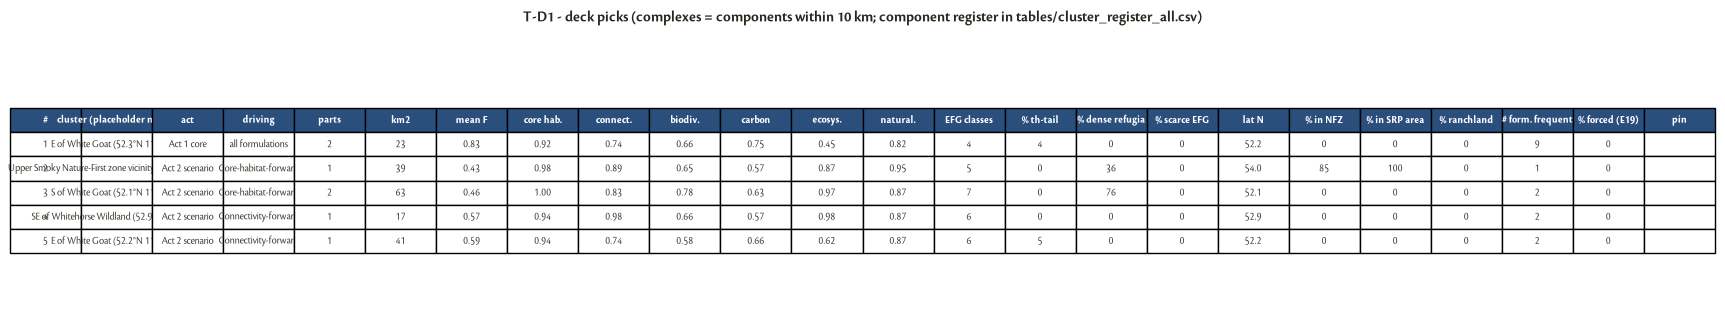

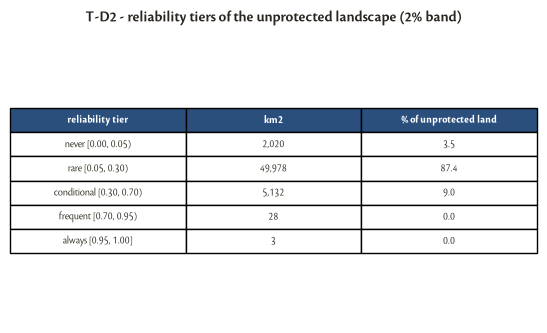

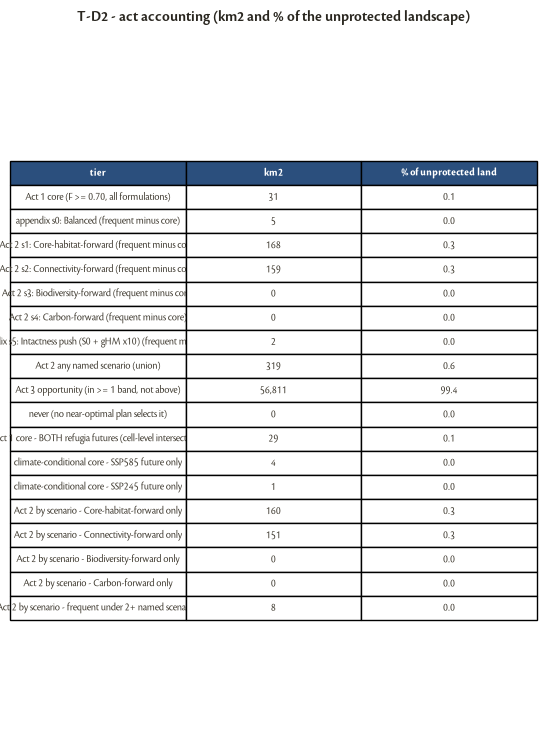

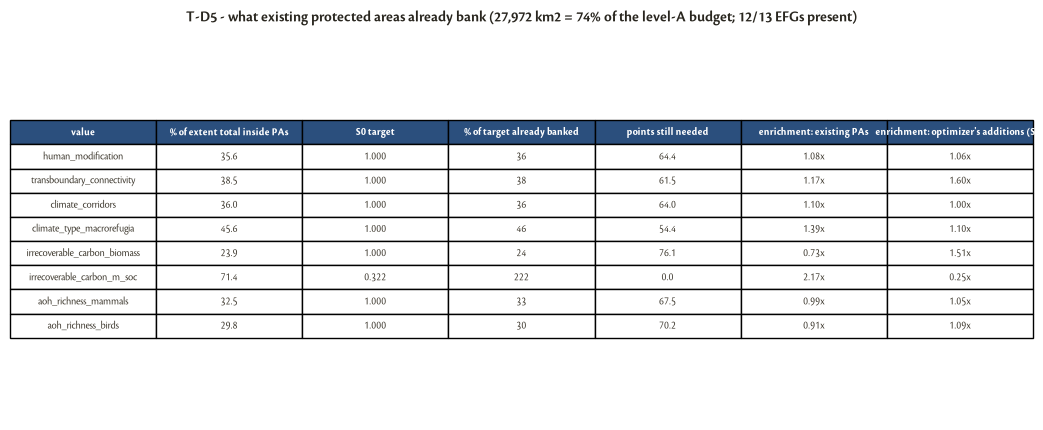

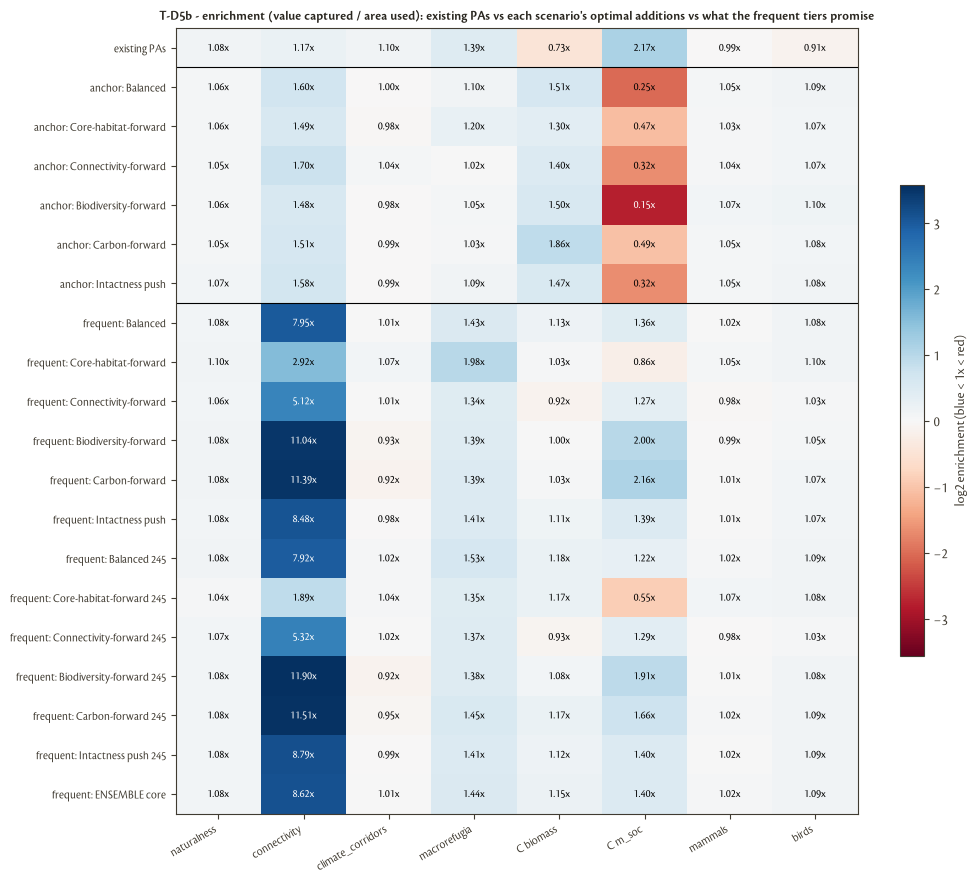

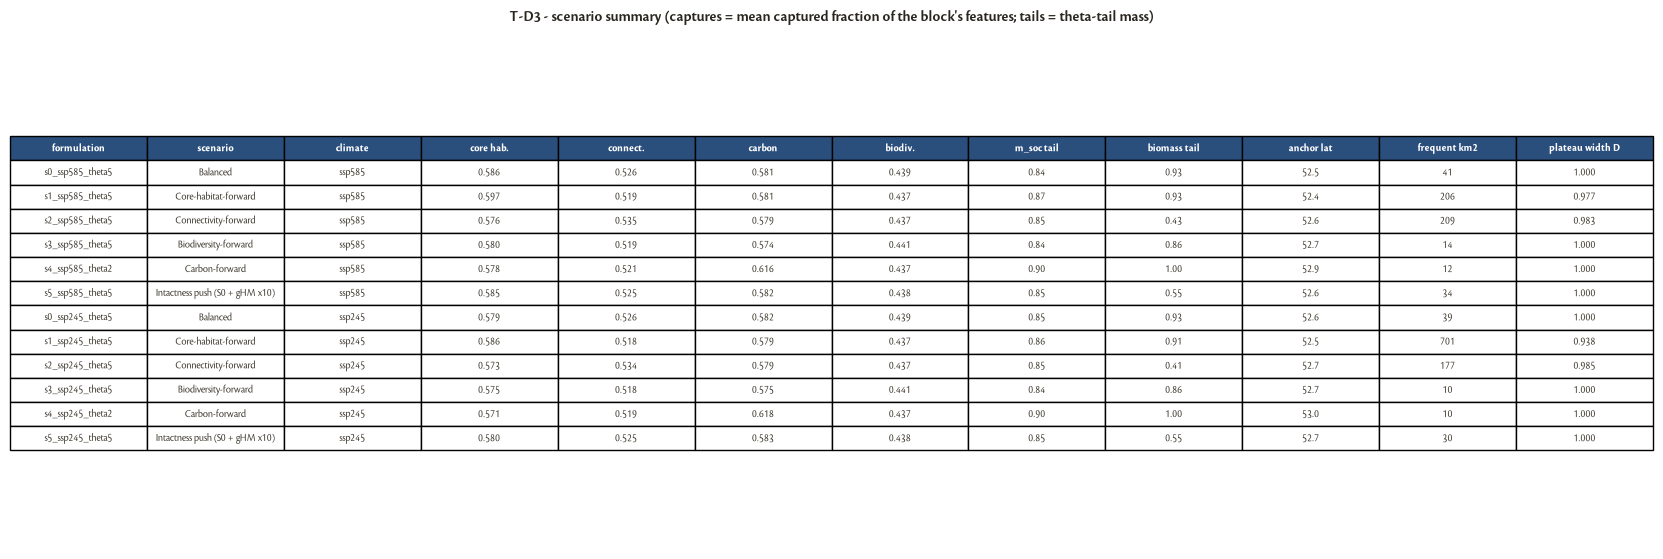

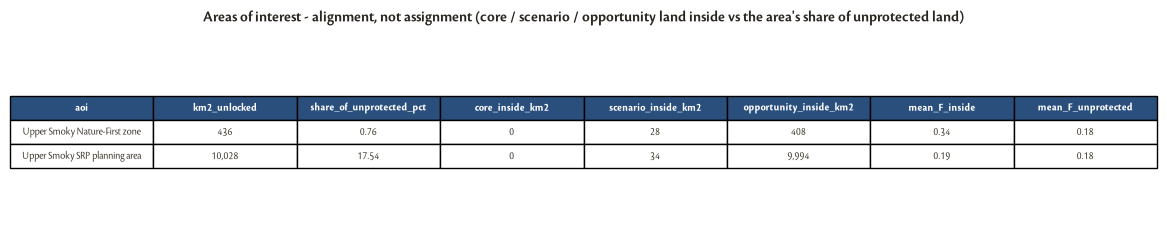

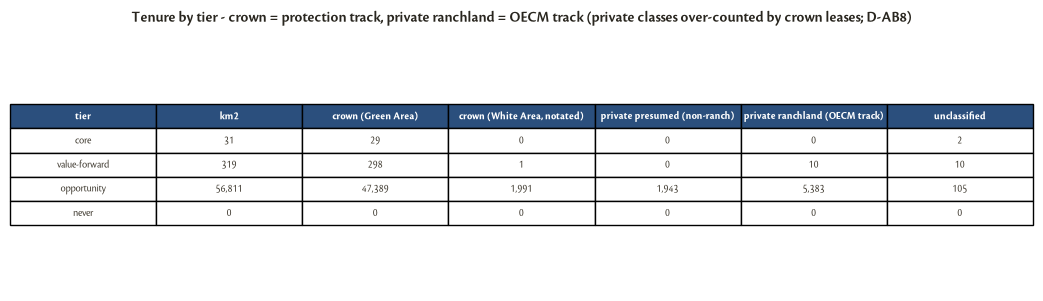

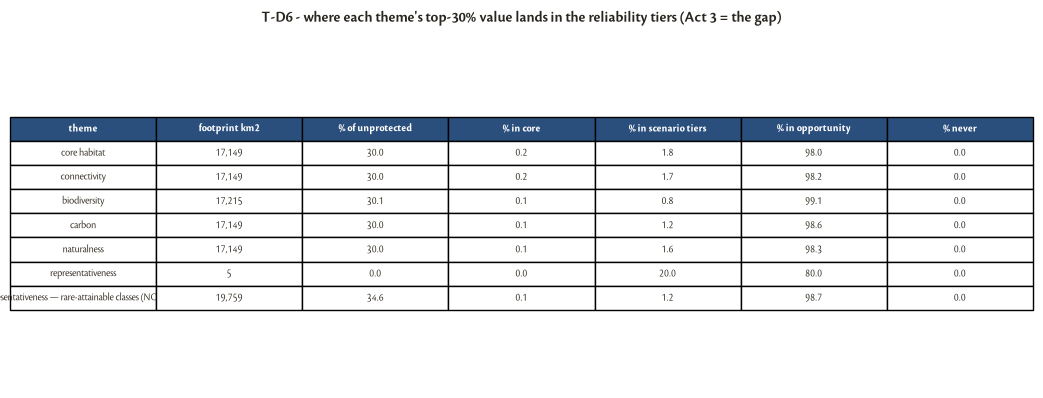

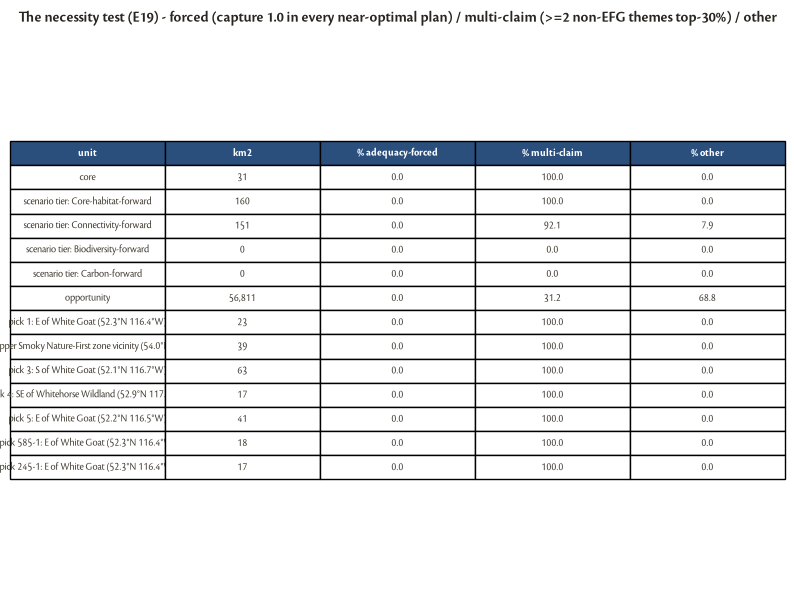

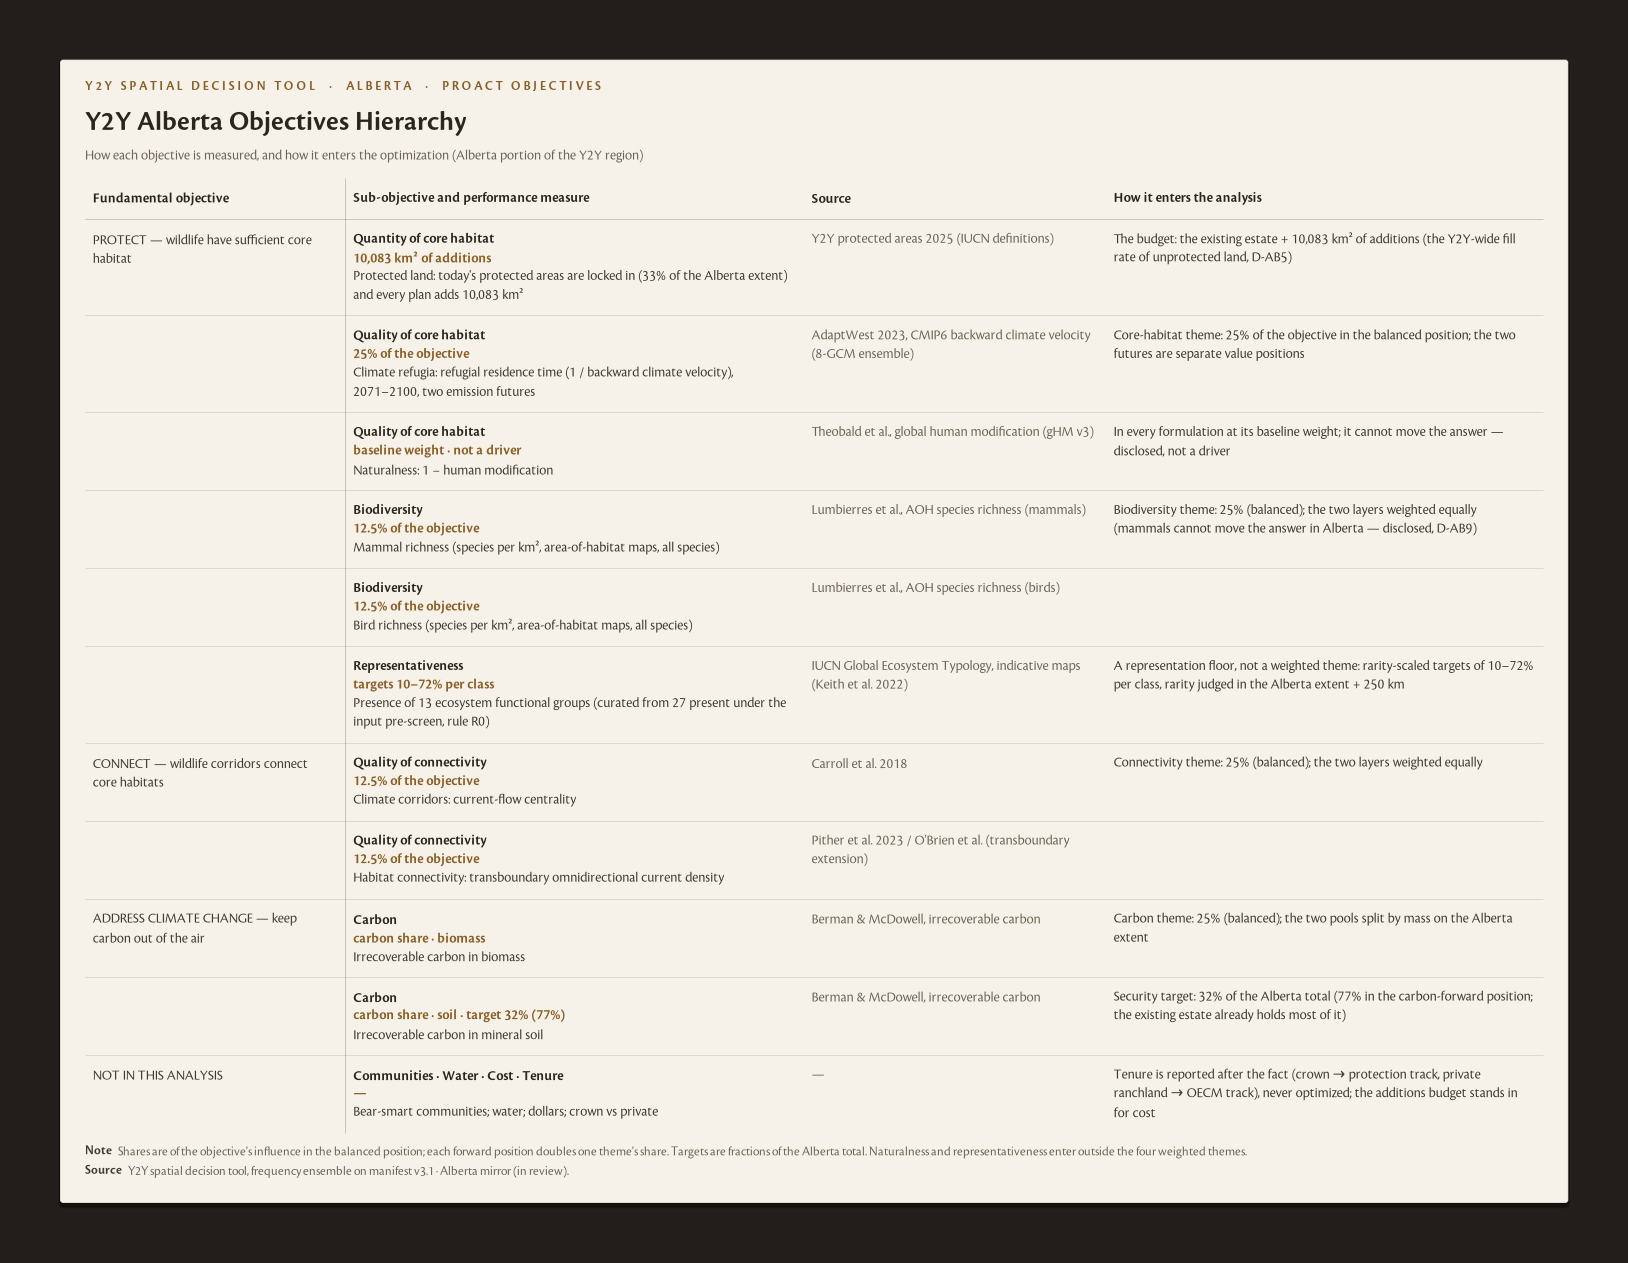

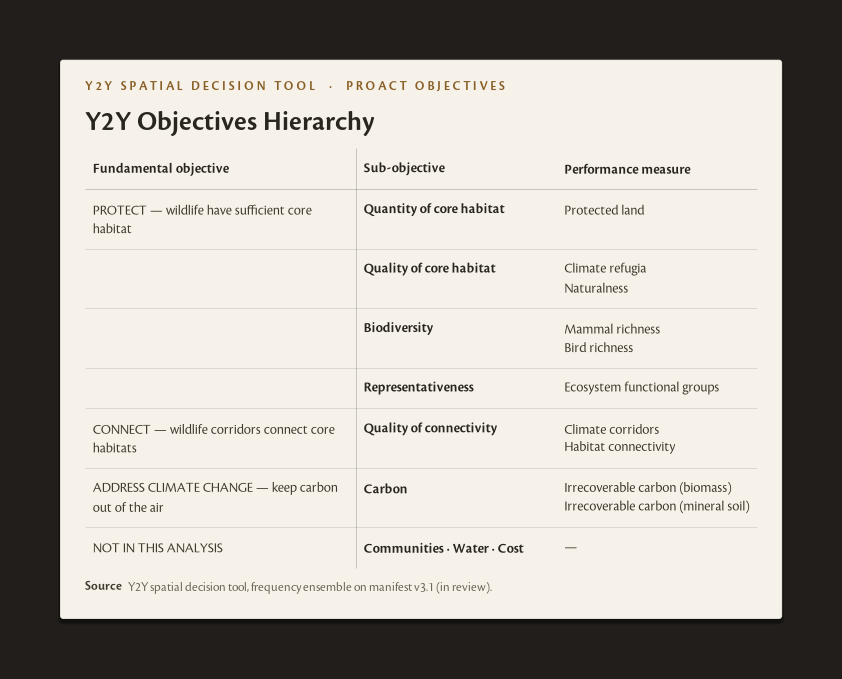

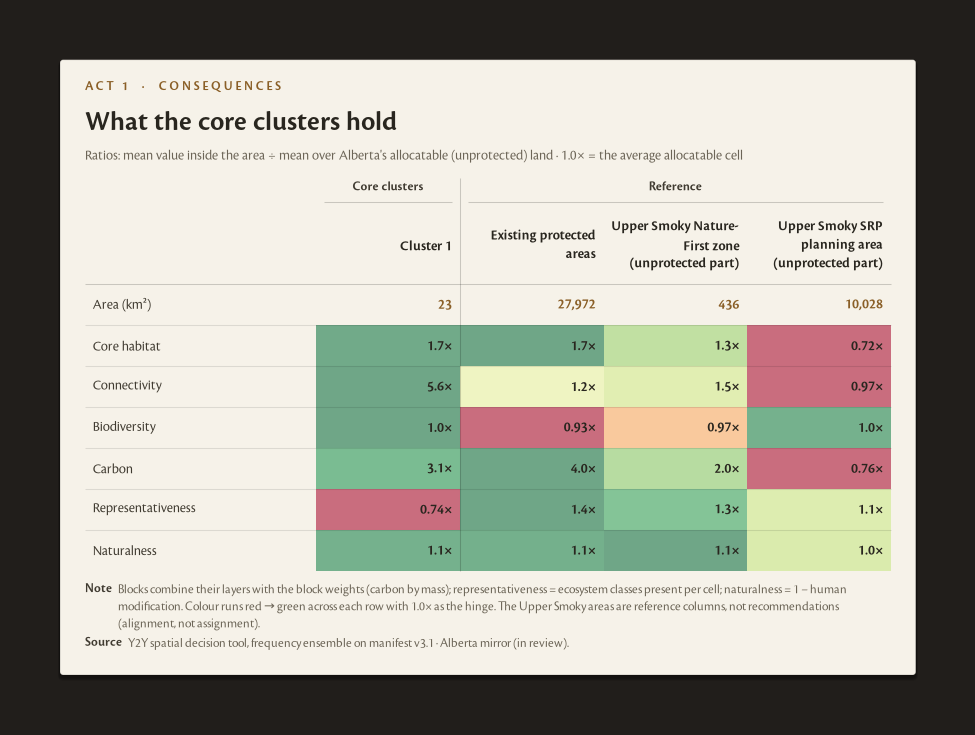

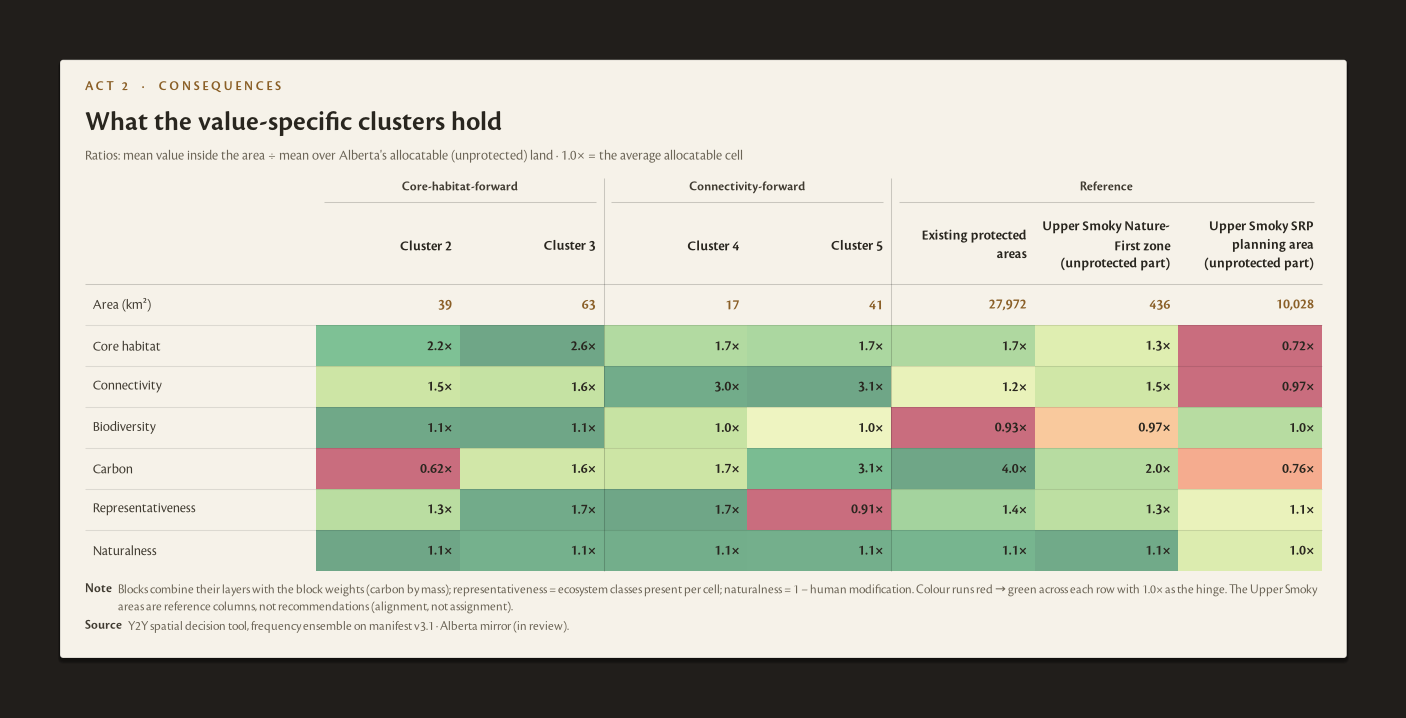

In [11]:
# ---- rendered tables (T-D1 picks, T-D2, T-D3, T-D5, T-D5b, AOI, tenure) ------------------------------------------------------
pk = TD1[TD1.act.isin(["Act 1", "Act 2"]) & TD1.number.notna() & (TD1.number != "")].copy(); pk["number"] = pk.number.astype(int); pk = pk.sort_values("number")
d1 = pd.DataFrame({"#": pk.number.astype(int), "cluster (placeholder name)": pk["name"], "act": pk.act_v16, "driving": pk.driving_label, "parts": pk.n_components.astype(int),
                   "km2": pk.area_km2.map("{:,.0f}".format), "mean F": pk.mean_guarded_F.map("{:.2f}".format), "core hab.": pk["pct_core habitat"].map("{:.2f}".format),
                   "connect.": pk.pct_connectivity.map("{:.2f}".format), "biodiv.": pk.pct_biodiversity.map("{:.2f}".format), "carbon": pk.pct_carbon.map("{:.2f}".format),
                   "ecosys.": pk.pct_representativeness.map("{:.2f}".format), "natural.": pk.pct_naturalness.map("{:.2f}".format), "EFG classes": pk.efg_classes_present.astype(int),
                   "% th-tail": pk["driver_m_soc theta-tail"].map("{:.0f}".format), "% dense refugia": pk[[c for c in pk.columns if c.startswith("driver_refugia")][0]].map("{:.0f}".format),
                   "% scarce EFG": pk[[c for c in pk.columns if c.startswith("driver_rarest")][0]].map("{:.0f}".format), "lat N": pk.mean_lat.map("{:.1f}".format),
                   "% in NFZ": pk.pct_in_NFZ.map("{:.0f}".format), "% in SRP area": pk.pct_in_SRP_area.map("{:.0f}".format), "% ranchland": pk.pct_private_ranchland.map("{:.0f}".format),
                   "# form. frequent": pk.n_formulations_frequent,
                   "% forced (E19)": pk.pct_adequacy_forced.map(lambda v: "-" if pd.isna(v) else f"{v:.0f}"),
                   "pin": pk.apply(lambda r: f"PIN: {r.adequacy_pin_class}" if bool(r.adequacy_pin) else "", axis=1)})
table_png(d1, FIGD / "td1_picks.png", f"T-D1 - deck picks (complexes = components within {S['complex_link_km']} km; component register in tables/cluster_register_all.csv)")
d2 = TD2a[["band", "guarded km2", "guarded %disc"]].copy(); d2.columns = ["reliability tier", "km2", "% of unprotected land"]
d2["km2"] = d2["km2"].map("{:,.0f}".format); d2["% of unprotected land"] = d2["% of unprotected land"].map("{:.1f}".format)
table_png(d2, FIGD / "td2_bands.png", f"T-D2 - reliability tiers of the unprotected landscape ({BANDPCT}% band)")
d2b = TD2b[["tier", "guarded km2", "guarded %disc"]].copy(); d2b.columns = ["tier", "km2", "% of unprotected land"]
d2b["km2"] = d2b["km2"].map("{:,.0f}".format); d2b["% of unprotected land"] = d2b["% of unprotected land"].map("{:.1f}".format)
table_png(d2b, FIGD / "td2_acts.png", "T-D2 - act accounting (km2 and % of the unprotected landscape)")
TD5 = pd.read_csv(TAB / "T-D5_protected_baseline.csv")
d5 = pd.DataFrame({"value": TD5.value, "% of extent total inside PAs": TD5.pct_of_extent_total_in_PAs.map("{:.1f}".format), "S0 target": TD5.S0_target.map("{:.3f}".format),
                   "% of target already banked": TD5.pct_of_target_already_banked.map("{:.0f}".format), "points still needed": TD5.pct_still_needed_from_unprotected_land.map("{:.1f}".format),
                   "enrichment: existing PAs": TD5.enrichment_existing_PAs.map("{:.2f}x".format), "enrichment: optimizer's additions (S0)": TD5.enrichment_S0_new_half.map("{:.2f}x".format)})
table_png(d5, FIGD / "td5_protected_baseline.png", f"T-D5 - what existing protected areas already bank ({S['protected_baseline']['pa_km2']:,} km2 = {S['protected_baseline']['pa_pct_of_budget']:.0f}% of the level-A budget; "
          f"{S['protected_baseline']['efg_present_in_PAs']}/{len(lc.efg_paths(AB))} EFGs present)")
TD5b = pd.read_csv(TAB / "T-D5b_enrichment_by_scenario.csv", index_col=0)
cols = ["existing PAs"] + [c for c in TD5b.columns if c.startswith("anchor") and "585" in c] + [c for c in TD5b.columns if c.startswith("frequent")]
M5 = TD5b[cols].T; M5.index = [i.replace("frequent tier - ", "frequent: ").replace("anchor - ", "anchor: ").replace(" 585", "") for i in M5.index]
M5.columns = [c.replace("irrecoverable_carbon_", "C ").replace("climate_type_", "").replace("aoh_richness_", "").replace("transboundary_", "").replace("human_modification", "naturalness") for c in M5.columns]
fig, ax = plt.subplots(figsize=(11, 0.42 * len(M5) + 1.8)); vals = M5.values.astype(float); vmax = float(np.nanmax(np.abs(np.log2(np.where(vals > 0, vals, np.nan)))))
im = ax.imshow(np.log2(np.where(vals > 0, vals, np.nan)), cmap="RdBu", vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(range(len(M5.columns))); ax.set_xticklabels(M5.columns, rotation=30, ha="right", fontsize=8.5); ax.set_yticks(range(len(M5))); ax.set_yticklabels(M5.index, fontsize=8.5)
for i in range(len(M5)):
    for j in range(len(M5.columns)):
        v = vals[i, j]; ax.text(j, i, "-" if np.isnan(v) else f"{v:.2f}x", ha="center", va="center", fontsize=8, color="white" if (v > 0 and abs(np.log2(v)) > 0.6 * vmax) else "black")
ax.axhline(0.5, color="black", lw=0.8); ax.axhline(0.5 + sum(1 for i in M5.index if i.startswith("anchor")), color="black", lw=0.8)
ax.set_title("T-D5b - enrichment (value captured / area used): existing PAs vs each scenario's optimal additions vs what the frequent tiers promise", fontsize=9.5)
fig.colorbar(im, ax=ax, shrink=0.6, label="log2 enrichment (blue < 1x < red)"); fig.savefig(FIGD / "td5b_enrichment_by_scenario.png", dpi=200, bbox_inches="tight"); plt.show()
d3 = pd.DataFrame({"formulation": TD3.formulation, "scenario": TD3.scenario, "climate": TD3.climate, "core hab.": TD3.capture_core_habitat.map("{:.3f}".format),
                   "connect.": TD3.capture_connectivity.map("{:.3f}".format), "carbon": TD3.capture_carbon.map("{:.3f}".format), "biodiv.": TD3.capture_biodiversity.map("{:.3f}".format),
                   "m_soc tail": TD3.tail_m_soc.map("{:.2f}".format), "biomass tail": TD3.tail_biomass.map("{:.2f}".format), "anchor lat": TD3.anchor_mean_lat.map("{:.1f}".format),
                   "frequent km2": TD3.frequent_km2_guarded.map("{:,}".format), "plateau width D": TD3.D_guarded.map("{:.3f}".format)})
table_png(d3, FIGD / "td3_scenarios.png", "T-D3 - scenario summary (captures = mean captured fraction of the block's features; tails = theta-tail mass)")
TAOI = pd.read_csv(TAB / "T-AOI_alignment.csv"); da = TAOI[["aoi", "km2_unlocked", "share_of_unprotected_pct", "core_inside_km2", "scenario_inside_km2", "opportunity_inside_km2", "mean_F_inside", "mean_F_unprotected"]].copy()
for c in da.columns[1:]: da[c] = da[c].map(lambda v: f"{v:,.2f}" if isinstance(v, float) else f"{v:,}")
table_png(da, FIGD / "t_aoi_alignment.png", "Areas of interest - alignment, not assignment (core / scenario / opportunity land inside vs the area's share of unprotected land)")
TEN = pd.read_csv(TAB / "T-TEN_tenure_by_tier.csv"); t2 = TEN.copy()
for c in t2.columns[1:]: t2[c] = t2[c].map("{:,.0f}".format)
table_png(t2, FIGD / "t_tenure_by_tier.png", "Tenure by tier - crown = protection track, private ranchland = OECM track (private classes over-counted by crown leases; D-AB8)")
d6 = TD6.copy(); d6.columns = ["theme", "footprint km2", "% of unprotected", "% in core", "% in scenario tiers", "% in opportunity", "% never"]
d6["footprint km2"] = d6["footprint km2"].map("{:,.0f}".format)
for c_ in d6.columns[2:]: d6[c_] = d6[c_].map("{:.1f}".format)
table_png(d6, FIGD / "td6_value_coverage.png", "T-D6 - where each theme's top-30% value lands in the reliability tiers (Act 3 = the gap)")
E19P_CSV = TAB / "E19_partition.csv"
if E19P_CSV.exists():
    e19p = pd.read_csv(E19P_CSV)
    d19 = pd.DataFrame({"unit": e19p.unit, "km2": e19p.km2.map("{:,.0f}".format), "% adequacy-forced": e19p.forced_pct.map("{:.1f}".format),
                        "% multi-claim": e19p.multi_claim_pct.map("{:.1f}".format), "% other": e19p.other_pct.map("{:.1f}".format)})
    table_png(d19, FIGD / "td_e19_partition.png", "The necessity test (E19) - forced (capture 1.0 in every near-optimal plan) / multi-claim (>=2 non-EFG themes top-30%) / other")

# ---- the objectives table (T-D0) and the T-D7 consequences tables: shared assets (director_plot.values_table / core_consequences /
# scenario_consequences) rendered to the Y2Y table spec; the Alberta rows come from 12's record (T-D0_values_rows.csv)
ROWS0 = pd.read_csv(TAB / "T-D0_values_rows.csv").fillna("")
dp.values_table(C, FIGD / "values_table.png", "Y2Y Alberta Objectives Hierarchy", rows=ROWS0[dp.VALUES_COLUMNS].values.tolist(), metrics=ROWS0.metric.tolist(),
                label="Y2Y SPATIAL DECISION TOOL  ·  ALBERTA  ·  PROACT OBJECTIVES",
                units="How each objective is measured, and how it enters the optimization (Alberta portion of the Y2Y region)")
dp.values_table_simple(C, FIGD / "values_table_simple.png")
if len(C.numbered("Act 1")):
    dp.core_consequences(C, FIGD / "td7_consequences_core.png")
else:
    print("no core clusters -- no Act 1 consequences table")
if len(C.numbered("Act 2")):
    dp.scenario_consequences(C, FIGD / "td7_consequences_scenarios.png")


In [12]:
# ---- deck outline + draft pptx (acts 0-3 per M4.33; consequences at the end of each act; E19 appendix) ---------------------------------------------------
e11 = S["e11_pairs_in_band"]; core_km2 = S["frequent_km2"]["guarded"]; pb = S["protected_baseline"]
slides = [
 dict(title="Alberta: where Y2Y's values agree - and what that means with a third already protected", image=None,
      bullets=[f"12 value positions (6 scenarios x 2 refugia futures) x 51 near-optimal plans each, on the Alberta portion of the Y2Y region ({G.n_pu:,} km2)",
               f"Existing parks are locked in: {pb['pa_km2']:,} km2 = {pb['pa_pct_of_region']:.0f}% of the extent - above the 30x30 areal target - and already bank "
               f"{pb['banked_min']:.0f}-{pb['banked_max']:.0f}% of every value ({pb['efg_present_in_PAs']}/{S['n_efg']} ecosystem groups present)",
               f"Additions budget {S['additions_km2']:,} km2 (the Y2Y-wide fill rate); unprotected land is {S['crown_share_of_unprotected_pct']:.0f}% crown; the private-ranchland (OECM) pool is ~{S['ranchland_pool_km2']:,} km2",
               f"Representativeness block curated before this run (rule R0, inherited from the Y2Y-wide analysis): {S['n_efg']} ecosystem features kept of 27 - anthropogenic biomes, "
               "a point-record class and one uninformative envelope removed; two duplicate footprints merged; targets scaled by rarity in the Alberta +250 km window",
               f"Every plan keeps every value theme within 5% of its best; the maps use the {BANDPCT}% band ({S['applied_band_rule']})",
               "The spine of the story: VALUE (where a theme is rich) is not IRREPLACEABILITY (where near-optimal plans cannot do without it)"],
      notes="Context. Methods: AB spec v0.5 mirror of the Y2Y-wide study plan v0.17.3; results_log R1-R8."),
 dict(title="How to read the maps", image=FIGD / "slide2_how_to_read.png",
      bullets=["Grey = existing protected areas (fixed in every plan; never a recommendation)", "1 km cells are the analysis AND display unit here (hexes shown only for comparison with the Y2Y-wide deck)",
               "Orange = the Upper Smoky Nature-First zone (solid) and planning area (dashed) - not locked in; overlap is independent convergence", "51 near-optimal plans x 12 value positions",
               "Ecosystem classes (IUCN GET) are coarse indicative maps (10 arcmin-1 degree grain): they enter as a representation floor, never draw a boundary, and any cluster they force is captioned as an adequacy pin"]),
 dict(title="The values in the analysis", image=FIGD / "values_table.png",
      bullets=["The PROACT objectives hierarchy: fundamental objective -> sub-objective -> the layer that measures it -> how it enters the optimization",
               "Four weighted themes share the objective equally in the balanced position; each forward position doubles one theme's share",
               "Representativeness is a floor (rarity-scaled targets on the curated block), not a weighted theme; naturalness is in the formulation but cannot move the answer",
               "Tenure, communities, water and cost are not optimized; the additions budget stands in for cost"]),
 dict(title="Act 0 - Where the values are", image=FIGD / "act0_values_1km.png",
      bullets=["Each PROACT theme's value before any optimization: the top 30% of Alberta's unprotected land by that theme",
               "Footprints: " + ", ".join(f"{t} {SV['footprint_km2'][t]:,} km2" for t in dc.VALUE_THEMES),
               "Representativeness votes as presence of an ecosystem class rare in the Alberta +250 km window; naturalness shown sixth - disclosed, not a driver",
               "This is the map directors already hold in their heads; the next acts ask what of it can be promised"]),
 dict(title="Act 0 - Where the values converge", image=FIGD / "act0_value_convergence_1km.png",
      bullets=["Count of the five themes (0-5) in which a cell is top-30%: " + ", ".join(f"{k}: {v:,} km2" for k, v in SV["convergence_km2"].items()),
               f"{SV['high_value_km2']:,} km2 ({100 * SV['high_value_km2'] / G.n_disc:.0f}% of unprotected land) is high-value for at least one theme",
               "Value is not irreplaceability: Acts 1-2 show how much of this the ensemble can promise"]),
 dict(title="Act 1 - Core commitments", image=FIGD / "act1_core_1km.png",
      bullets=[f"Of everything in Act 0, these areas recur in near-optimal plans no matter whose values prevail: {core_km2:,} km2 = {100 * core_km2 / G.n_disc:.1f}% of unprotected land (F >= 0.70 across all 12 positions)",
               "No value theme left more than 5% behind in any plan", "Numbered = the largest core clusters (full register in the appendix)"]),
 *[dict(title=f"Act 1 core under the {'high' if lv == '585' else 'low'}-emissions refugia future", image=LEV_FIGS[lv],
        bullets=[f"6 positions at SSP{lv}: core {S['by_level'][lv]['core_km2']:,} km2", f"{S['by_level'][lv]['pct_of_12_inside']:.0f}% of the 12-position core lies inside it", "The 12-position core = what survives BOTH refugia futures"]) for lv in LEV_FIGS],
 dict(title="Where the promise depends on the climate future", image=FIGD / "act1_two_way_climate.png",
      bullets=["One cell, two refugia futures", "Yellow = core under both futures; orange = only if emissions run high; green = only if they stay low"]),
 *([dict(title="Why these places - core clusters", image=FIGD / "act1_star_grid.png",
      bullets=["Block percentiles vs Alberta's allocatable land (0.5 = typical); clusters numbered north -> south", "Core clusters spike on BINDING claims rather than excelling everywhere; any cluster the ecosystem block forces is captioned ADEQUACY PIN"])] if (FIGD / "act1_star_grid.png").exists() else []),
 *([dict(title="Act 1 - Consequences: what the core clusters hold", image=FIGD / "td7_consequences_core.png",
      bullets=["Each measure = the cluster's mean value / the mean over Alberta's allocatable land (1.0x = the average unprotected cell)",
               "Reference columns: existing protected areas; the Upper Smoky Nature-First zone and planning area (unprotected parts) - alignment, not assignment"])] if (FIGD / "td7_consequences_core.png").exists() else []),
 *[dict(title=f"Act 2 - {dc.SCENARIO_LABEL[k.split('@')[0]]}: value vs irreplaceability", image=ACT3_FIGS[k],
        bullets=["Left: where the theme's value is (Act 0). Right: what becomes irreplaceable when this value leads - its frequent tier, clusters outside the core numbered",
                 f"Frequent tier {int(((POOL[k] >= dc.FREQ_THR) & G.disc).sum()):,} km2; own land (outside the core and the other scenarios' tiers) {S['act2_owner_km2'][dc.SCENARIO_LABEL[k.split('@')[0]]]:,} km2",
                 "Orange = the Upper Smoky Nature-First zone and planning area - overlap is independent convergence, not assignment"]
                + ([dc.BIODIV_FINDING.format(lo=100 * BIO["min"], hi=100 * BIO["max"]) + " - the finding IS the product: the value map (left) is where to work"] if k.startswith("s3") else [])
                + (["Carbon-forward is the one scenario that also states a security target (m_soc t = 0.772 at Alberta's ladder); its tier is the target's doing (parent E18)", dc.CARBON_MIRROR] if k.startswith("s4") else []))
   for k in keys],
 dict(title="Scenario clusters - value profiles", image=FIGD / "act2_star_grid.png", bullets=["Each scenario's two largest clusters outside the core, numbered on from the core", "Same radial scale as the core stars"]),
 *([dict(title="Act 2 - Consequences: what the value-specific clusters hold", image=FIGD / "td7_consequences_scenarios.png",
         bullets=["Same measures and reference columns as Act 1; clusters grouped by the value that leads"])] if (FIGD / "td7_consequences_scenarios.png").exists() else []),
 dict(title="Hinge - value convergence x what can be promised", image=FIGD / "hinge_convergence_x_F.png",
      bullets=["Rows: how many themes rate the cell top-30%; columns: the ensemble's reliability class", "High value / core = the easy sell",
               "High value / opportunity = Act 3's territory - near-optimal plans absorb it", "Low value / core = binding claims in unglamorous places - point at it in the room"]),
 dict(title="Why these places (driver attribution)", image=FIGD / "why_these_places.png",
      bullets=["High frequency follows binding scarcity, not the most-valued layer"]
              + ([f"Leave-one-theme-out (S0): removing the ecosystem block shifts the optimal plan {[r for r in S['e17']['shifts'] if r['block_out'] == 'efg'][0]['delta_lat']:+.2f} degrees of latitude "
                  f"(Jaccard {[r for r in S['e17']['shifts'] if r['block_out'] == 'efg'][0]['jaccard_vs_s0']:.2f} with the full plan)"] if "e17" in S and any(r['block_out'] == 'efg' for r in S['e17']['shifts']) else [])),
 dict(title="Act 3 - The opportunity landscape: the measured gap", image=FIGD / "act3_opportunity.png",
      bullets=[f"{SV['gap_km2']:,} km2 of high-value land ({SV['gap_pct_of_high_value']:.0f}% of it) sits outside the core and every scenario tier",
               f"Near-optimal plans absorb it: {S['ever_in_band_pct']['guarded']:.0f}% of unprotected land appears in >=1 near-optimal plan at {BANDPCT}% ({S['ever_in_5pct_band_pct']:.0f}% within 5%); "
               f"{e11[0]}/{e11[1]} pairs of value positions are mutually near-optimal",
               "The analysis does not forbid working anywhere relationships and feasibility are positive - it tells you what can be promised about each tier", "PRIORITY != PERMISSION"]),
 dict(title="What each tier delivers", image=FIGD / "tier_achievement.png", bullets=["Value captured per theme by cumulative tier (PAs -> + core -> + scenario tiers -> + opportunity)", "Red line/band = what a single optimal plan captures", "The existing estate already banks most of every value; additions add at the margin (pairs with T-D6)"]),
 dict(title="Where, and on whose land", image=FIGD / "td4_natural_regions.png", bullets=["Tier area by Natural Region (2005); subregion table in the appendix", "Tenure by tier: crown = protection track, private ranchland = OECM track (t_tenure_by_tier.png)", "Private classes are over-counts: crown grazing leases are not separable without licensed data"]),
 dict(title="Areas of interest - alignment, not assignment", image=FIGD / "t_aoi_alignment.png", bullets=["Upper Smoky Nature-First zone (novel 436 km2) and the SRP planning area", "Core / scenario / opportunity land inside vs the area's share of unprotected land", "The zone was drawn for caribou and the existing parks, not for complementarity across these values - low core overlap is informative, not a contradiction"]),
 dict(title="What we can promise - the map in one picture", image=FIGD / "summary_tiers_1km.png", bullets=["Yellow = commit regardless of values (Act 1)", "Coloured = joins the core if that value leads (Act 2; dark blue = more than one)", "Light blue = defensible wherever feasibility is positive (Act 3)", "Tiers are levels of reliability, not a fence"]),
 dict(title="What we can promise", image=FIGD / "td2_bands.png", bullets=["Core: recurs under every value position (commit)", "Scenario tiers: join the core if that value leads (choose)", "Opportunity: defensible wherever feasibility is positive (enable)", "Next: cluster names (Tim), 'west of Grande Cache' from the value-forward surfaces, licensed tenure data if the OECM split must be parcel-true"]),
 *([dict(title="Appendix - The necessity test (E19): what the ecosystem block forces", image=FIGD / "td_e19_partition.png",
         bullets=[f"Adequacy-forced = a class captured in full by EVERY near-optimal plan of EVERY position: its cells have F = 1 by arithmetic, not by beating alternatives - {S['e19']['core_forced_pct']:.0f}% of the core",
                  f"Clusters >= 50% forced are captioned ADEQUACY PIN ('here because it is the only X on the extent'): {S['e19']['n_pins']} of the register",
                  "Multi-claim = not forced and rich for >= 2 other themes; other = the remainder"])] if "e19" in S else []),
]
lines = [f"# Alberta director package - deck outline (mirror of the Y2Y-wide record; acts 0-3 per M4.33)\n", f"_generated from {PKG.relative_to(ROOT)}; VERSION {S['version']}; n = {S['n_formulations']} positions; {BANDPCT}% band; level A_\n"]
for i, s in enumerate(slides, 1):
    lines.append(f"## Slide {i} - {s['title']}\n")
    if s.get("image"): lines.append(f"figure: `{pathlib.Path(s['image']).name}`\n")
    lines += [f"- {b}" for b in s.get("bullets", [])]
    if s.get("notes"): lines.append(f"\n> {s['notes']}")
    lines.append("")
lines += ["## Appendix", "- `act1_F_histogram.png`, `act1_core_1km_tiers.png` (five-tier analytic surface), `act1_core_ssp585_1km.png` / `act1_core_ssp245_1km.png`; `values_table.png` + `tables/T-D0_values.csv`",
          "- `td1_picks.png` + `tables/T-D1_cluster_register.csv` (full register, incl. % adequacy-forced), `tables/cluster_sensitivity.csv` (0.60/0.80; min size 10 km2)",
          "- `td6_value_coverage.png` + `tables/T-D6_value_coverage.csv` / `T-D6b_value_share_by_tier.csv`, `tables/hinge_crosstab.csv`, `td7_consequences_*.png` + `tables/T-D7_consequences.csv`, `td_e19_partition.png` + `tables/E19_partition.csv`",
          "- `td2_acts.png`, `td3_scenarios.png`, `td5_protected_baseline.png`, `td5b_enrichment_by_scenario.png`, `td4_natural_subregions.png`, `t_aoi_alignment.png`, `t_tenure_by_tier.png`, `tables/pooling_check.csv`, 1 km GeoTIFFs in `geotiffs/` (incl. `value_top30_*.tif`, `value_convergence.tif`, `value_gap.tif`)",
          "- `act2_scenarios_overview.png`, `agreement_matrix.png`, `tables/picks_raw_complexes.csv` (the complexes before regional grouping)", "- Open: cluster names (placeholders = nearest named area + bearing), AOI-3 'west of Grande Cache' (from the value-forward surfaces), D-AB8 tenure data"]
(PKG / "deck_outline.md").write_text("\n".join(lines))
dc.build_deck(slides, PKG / "alberta_director_deck.pptx")
print(f"wrote {PKG.relative_to(ROOT)}/deck_outline.md + alberta_director_deck.pptx ({len(slides)} slides; VERSION {S['version']})")


wrote analyses/alberta_prioritization/director_package/deck_outline.md + alberta_director_deck.pptx (26 slides; VERSION v3.1)
